<a href="https://colab.research.google.com/github/fxrdhan/ML_scikit-learn_Cookbook_O-Reilly/blob/main/Chapter_05_Linear_Models_and_Regularization/Chapter_05_Linear_Models_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Linear Models and Regularization

| | |
|---|---|
| **Book** | *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing, 2025) |
| **Library version targeted by the book** | scikit-learn 1.5 |
| **Version used to run this notebook** | scikit-learn 1.9.1 on Python 3.12 (printed by the setup cell) |
| **What this notebook contains** | reproduction of every code listing in the chapter and of the official exercise solutions, chapter and recipe summaries, theoretical deep-dives, and extra experiments |

## Chapter overview

Linear regression is probably the first model most of us meet, in school: a line that describes the relationship between data points. Chapter 5 starts from **ordinary least squares (OLS)** and moves to the methods that make linear models robust — the regularized regressions — and to methods that bend a linear model around non-linear data. It shows how to:

* fit and evaluate a **linear regression** with mean squared error and $R^2$;
* add an $L_2$ penalty (**ridge**) or an $L_1$ penalty (**Lasso**) to shrink coefficients, and let Lasso remove features;
* combine both penalties in **ElasticNet** and read a **coefficient path plot**;
* understand **regularization** as a trade-off between bias and variance;
* model curved relationships with **polynomial features** and **splines**;
* practise with three exercises on ridge, Lasso and ElasticNet.

### Recipes in this chapter

| # | Recipe | Code in the book | What this notebook adds |
|---|---|---|---|
| 1 | Introduction to linear models | Yes, 2 listings | OLS by hand, why the book's $R^2$ is so low (the target was generated before half the columns were overwritten), multicollinearity measured |
| 2 | Ridge and Lasso regression | Yes, 1 listing | Shrinkage versus soft-thresholding, scikit-learn's exact objectives, a tuned ridge and Lasso |
| 3 | ElasticNet and regularization | Yes, 1 listing | A readable coefficient path plot, the grouping effect on correlated features |
| 4 | Regularization theory and practice | No | Why $L_1$ produces zeros (the geometry), the bias–variance curve of ridge measured |
| 5 | Regression and regularization (polynomials and splines) | Yes, 3 listings | A scikit-learn 1.9 change that breaks the degree-5 fit, degree and knots chosen by cross-validation |
| 6 | Practical exercises with regularization techniques | Official solutions | Why a straight ridge line cannot fit a parabola, how much Lasso shrinks a true slope, the four models compared |

### How to read this notebook

Every recipe has the same structure:

1. **Summary** — what the book says, condensed.
2. **Theory** — the ideas behind it: math, algorithms and design reasoning.
3. **Book code** — the listing reproduced from the book (page numbers refer to the printed edition), followed by an **output analysis**.
4. **Extra** — experiments written for this notebook to make the theory concrete. They are *not* part of the book.

Every code cell starts with a label comment: `# BOOK CODE` for a listing reproduced from the book, `# EXTRA` for code written for this notebook.

---
## 0. Setup

Every dataset in this chapter is generated with fixed seeds or ships with scikit-learn (`load_diabetes`), so the notebook runs offline. Recipe 5's book code uses **seaborn** for one scatter plot. The setup cell:

* prints the library versions;
* fixes a global seed, because the book's first dataset draws random noise without a seed;
* silences one harmless scikit-learn warning about feature names, which the book's listings trigger on every prediction (explained in recipe 1);
* defines the plotting style used by the extra figures.

In [1]:
import platform
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn
import sklearn
from matplotlib import patheffects

print(f"Python       : {platform.python_version()}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"SciPy        : {scipy.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {seaborn.__version__}")

sk_version = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
assert sk_version >= (1, 5), "This notebook needs scikit-learn >= 1.5 -> pip install -U scikit-learn"

# Global seed: the book adds unseeded noise to its first dataset, so this fixes the data
np.random.seed(0)

# The book's listings fit on NumPy arrays and predict from DataFrames (or the reverse), so scikit-learn
# warns about feature names on every call. The column order is the same, so the warnings are harmless
# here; they are silenced to keep the outputs readable (see recipe 1).
warnings.filterwarnings("ignore", message="X has feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# A quiet, colour-blind-safe style used by the extra figures in this notebook
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua (checked for colour-vision deficiency)
INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 10,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_SOFT, "ytick.labelcolor": INK_SOFT,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2, "legend.frameon": False, "legend.labelcolor": INK_SOFT,
    "figure.dpi": 110, "font.size": 10,
})

Python       : 3.12.3
scikit-learn : 1.9.1
NumPy        : 2.5.3
SciPy        : 1.18.1
pandas       : 3.0.6
Matplotlib   : 3.11.2
seaborn      : 0.13.2


---
## 1. Introduction to linear models

### Summary

* Linear models are the backbone of many predictive techniques, and the foundation for regularized regression and logistic regression.
* **Getting ready** — a synthetic dataset, built in four steps:
  1. `make_regression(n_samples=1000, n_features=100, n_informative=10, noise=20, random_state=123)`.
  2. "High multicollinearity": columns 50–99 are overwritten with copies of columns 0–49 plus a little noise.
  3. The target is multiplied by 1,000 and gets a sine and an exponential term of `feature_0` "to add some non-linearity".
  4. The data go into a DataFrame, and the target is plotted against `feature_0` (Figure 5.1).
* **How to do it:**
  * Split 80/20 (`random_state=123`), fit `LinearRegression`, and report the **mean squared error (MSE)** and $R^2$ on the test set.
  * Plot the fitted line along `feature_0`, with all other features set to 0 (Figure 5.2).
* **How it works:** linear regression models the target as $y = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p + \epsilon$, with an intercept, one coefficient per feature and an error term.
* **There's more:** regularized regression (ridge and Lasso) penalizes large coefficients, and logistic regression extends linear models to class probabilities (Chapter 6).
* **Hands-on exercises:** choose a regression dataset, clean it, fit `LinearRegression`, compute MSE and $R^2$, and plot predictions or residuals.

### Theory: ordinary least squares

With the features in an $n \times p$ matrix $\mathbf{X}$ (plus a column of ones for the intercept), OLS chooses the coefficients that minimize the **residual sum of squares**:

$$\hat{\boldsymbol\beta} = \arg\min_{\boldsymbol\beta} \lVert \mathbf{y} - \mathbf{X}\boldsymbol\beta \rVert^2 .$$

Setting the gradient to zero gives the **normal equations** $\mathbf{X}^\top\mathbf{X}\,\hat{\boldsymbol\beta} = \mathbf{X}^\top\mathbf{y}$. When $\mathbf{X}^\top\mathbf{X}$ is invertible,

$$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}.$$

Geometrically, $\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol\beta}$ is the orthogonal projection of $\mathbf{y}$ onto the space spanned by the columns, so the residuals are orthogonal to every feature. scikit-learn's `LinearRegression` does not invert $\mathbf{X}^\top\mathbf{X}$. It solves the least-squares problem with an SVD (`scipy.linalg.lstsq`), which also copes with nearly dependent columns.

**Statistical properties.** If the errors have mean zero, constant variance $\sigma^2$ and no correlation, OLS is the best linear unbiased estimator (Gauss–Markov), with

$$\operatorname{Var}(\hat{\boldsymbol\beta}) = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}.$$

**Multicollinearity.** When some columns are almost linear combinations of others, $\mathbf{X}^\top\mathbf{X}$ is nearly singular, and the variance of the affected coefficients explodes. The *variance inflation factor* measures this for feature $j$:

$$\mathrm{VIF}_j = \frac{1}{1 - R_j^2},$$

where $R_j^2$ is the $R^2$ of regressing feature $j$ on all the other features. A VIF above 10 is the usual alarm. The *predictions* can still be fine; it is the individual coefficients that become unstable and uninterpretable. Ridge regression (recipe 2) was invented for exactly this problem.

**The metrics.**

* $\text{MSE} = \frac{1}{n}\sum_i (y_i - \hat y_i)^2$ is in squared units of the target, so multiplying the target by 1,000 multiplies the MSE by $10^6$.
* $R^2 = 1 - \text{SSE}/\text{SST}$ (Chapter 1) is unit-free: the share of the target's variance that the model explains on the evaluated data. It is negative when the model is worse than predicting the mean.

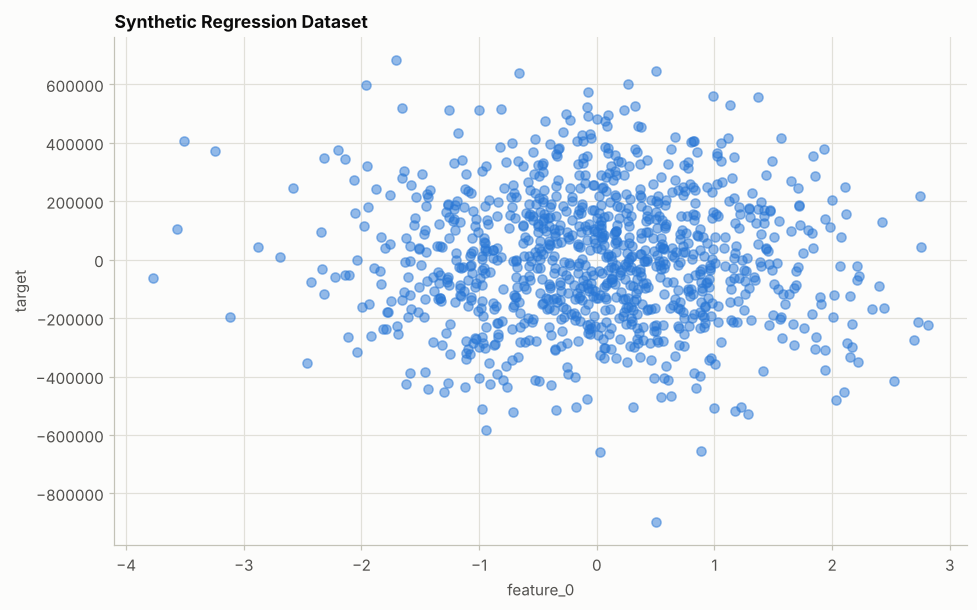

In [2]:
# BOOK CODE: Introduction to linear models -- getting ready (pp. 94-96)
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Create synthetic regression dataset with high multicollinearity and more features
X, y = make_regression(n_samples=1000,
                      n_features=100,
                      n_informative=10,
                      noise=20,
                      random_state=123)

# Add multicollinearity by creating correlated features
for i in range(50, 100):  # Make half the features correlated
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

# Create feature names
feature_names = [f'feature_{i}' for i in range(100)]

# Take just the first feature for visualization
X_plot = X[:, 0].reshape(-1, 1)

# Add some non-linearity and make coefficients vary widely in magnitude
y = y * 1000  # Scale up the target
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel()/10)

# Convert to pandas DataFrame with feature names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df_plot = pd.DataFrame({'feature_0': X_plot.ravel(), 'target': y})

# Quick visualization of the data
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

Mean Squared Error: 49712054061.09
R-squared: 0.00


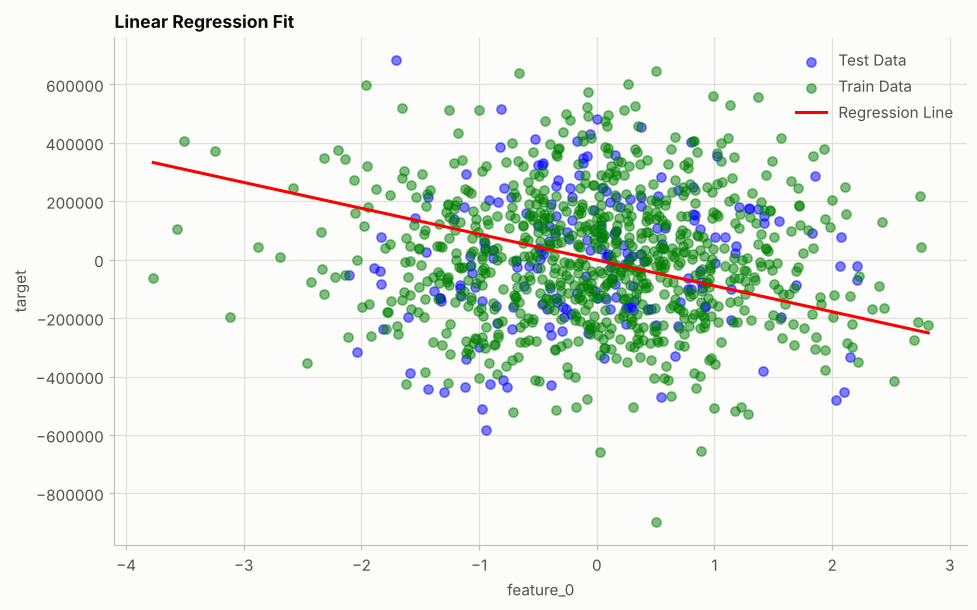

In [3]:
# BOOK CODE: Introduction to linear models -- how to do it (pp. 96-98)
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate performance using MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

# Visualize the data and regression line (using feature_0 for visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.5, label='Train Data')

# Sort the data for a smooth line plot
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()  # Set feature_0, leave others as 0
y_line = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.plot(X_line, y_line, color='red', label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

**Output analysis.**

* **The data.** Along `feature_0` the target is a shapeless cloud (Figure 5.1, "very random, but mostly normally distributed"). This is expected: `feature_0` is not one of the informative features, and the plot shows a single feature out of 100.
* **The model explains almost nothing.** The test $R^2$ is essentially 0 (the run stored in the official notebook printed 0.06), and the MSE is in the tens of billions only because the target was multiplied by 1,000. The noise added to columns 50–99 is drawn without a seed, so the exact numbers differ from run to run in the book's setting; this notebook fixes the global seed.

  The real cause of the poor fit is in the data construction, not in OLS. Extra (b) shows that most of the target's signal was destroyed when the columns were overwritten.
* **The "non-linearity" is invisible.** The sine and exponential terms have a standard deviation of about 100, while the scaled target's standard deviation is in the hundreds of thousands.
* **The fitted line** shows the model's prediction when only `feature_0` varies and all other features are 0. Its slope is the coefficient of `feature_0`.
* **A warning silenced in the setup cell.** Run as printed, this listing warns "X has feature names, but LinearRegression was fitted without feature names". The model was fitted on a NumPy array but asked to predict from a DataFrame. scikit-learn checks column names whenever it has seen them; here the order is the same, so the warning is harmless. Fitting and predicting with the same type (both arrays, or both DataFrames) avoids it.

In [4]:
# EXTRA: (a) OLS by hand -- the normal equations give the same coefficients as LinearRegression
X_design = np.column_stack([np.ones(len(X_train)), X_train])            # a column of ones for the intercept
beta = np.linalg.solve(X_design.T @ X_design, X_design.T @ y_train)    # (X^T X) beta = X^T y
print("intercept: by hand", round(beta[0], 2), "| sklearn", round(linear_model.intercept_, 2))
print("largest coefficient difference:", f"{np.abs(beta[1:] - linear_model.coef_).max():.2e}",
      "(relative to a typical coefficient of", f"{np.abs(linear_model.coef_).mean():.0f})")
residuals = y_train - linear_model.predict(X_train)
print("residuals are orthogonal to every feature: largest |X^T r| / (|X| |r|) =",
      f"{np.max(np.abs(X_train.T @ residuals) / (np.linalg.norm(X_train, axis=0) * np.linalg.norm(residuals))):.1e}")

intercept: by hand -1138.32 | sklearn -1138.32
largest coefficient difference: 3.04e-08 (relative to a typical coefficient of 59507)
residuals are orthogonal to every feature: largest |X^T r| / (|X| |r|) = 1.2e-15


In [5]:
# EXTRA: (b) Why the model explains almost nothing -- the target was built before the columns were overwritten
X_orig, y_orig, true_coef = make_regression(n_samples=1000, n_features=100, n_informative=10, noise=20,
                                            random_state=123, coef=True)       # the same call, now returning the coefficients
informative = np.flatnonzero(true_coef)
overwritten = informative[informative >= 50]
print("informative columns:", informative.tolist())
print("of which overwritten by the multicollinearity loop:", overwritten.tolist())
signal_kept = np.var(X_orig[:, informative[informative < 50]] @ true_coef[informative[informative < 50]])
signal_lost = np.var(X_orig[:, overwritten] @ true_coef[overwritten])
print(f"share of the signal's variance carried by the overwritten columns: {signal_lost / (signal_kept + signal_lost):.0%}")

Xo_train, Xo_test, yo_train, yo_test = train_test_split(X_orig, y_orig * 1000, test_size=0.2, random_state=123)
print(f"test R2 of OLS on the original columns: {LinearRegression().fit(Xo_train, yo_train).score(Xo_test, yo_test):.3f}"
      f" | on the book's overwritten columns: {linear_model.score(X_test, y_test):.3f}")
print(f"std of the scaled target: {(y_orig * 1000).std():,.0f} | std of the added sine + exp terms: "
      f"{(np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel() / 10)).std():.0f}")

informative columns: [3, 21, 25, 66, 68, 71, 75, 81, 98, 99]
of which overwritten by the multicollinearity loop: [66, 68, 71, 75, 81, 98, 99]
share of the signal's variance carried by the overwritten columns: 77%
test R2 of OLS on the original columns: 0.992 | on the book's overwritten columns: 0.001
std of the scaled target: 223,821 | std of the added sine + exp terms: 98


In [6]:
# EXTRA: (c) Multicollinearity measured -- variance inflation and unstable coefficients
def vif(X_mat, j):
    others = np.delete(X_mat, j, axis=1)
    r2_j = LinearRegression().fit(others, X_mat[:, j]).score(others, X_mat[:, j])
    return 1 / (1 - r2_j)

print(f"VIF of feature_0: {vif(X_train, 0):.0f} | of feature_50 (its noisy copy): {vif(X_train, 50):.0f}")
print(f"correlation of feature_0 and feature_50: {np.corrcoef(X_train[:, 0], X_train[:, 50])[0, 1]:.4f}")

rng = np.random.default_rng(0)
boot = []
for _ in range(100):                                     # refit OLS on bootstrap resamples of the training set
    idx = rng.integers(0, len(X_train), len(X_train))
    c = LinearRegression().fit(X_train[idx], y_train[idx]).coef_
    boot.append((c[0], c[50], c[0] + c[50]))
boot = pd.DataFrame(boot, columns=["coef of feature_0", "coef of feature_50", "their sum"])
display(boot.agg(["mean", "std"]).round(0))

VIF of feature_0: 121 | of feature_50 (its noisy copy): 121
correlation of feature_0 and feature_50: 0.9953


,coef of feature_0,coef of feature_50,their sum
mean,-90131.0,84363.0,-5768.0
std,69076.0,68397.0,8317.0


**Output analysis.**

* **(a) By hand.** The normal equations give the same intercept and coefficients as `LinearRegression`, up to round-off. The residuals are orthogonal to every feature, which is the projection property of OLS.
* **(b) The real reason for the low $R^2$:**
  * `make_regression` chose 10 informative columns, and **7 of them lie in columns 50–99**: the loop then replaced them with noisy copies of columns 0–49.
  * The target still contains their contribution — about three quarters of the signal's variance — but the features that produced it are gone, so no model can explain it.
  * On the original columns, OLS reaches $R^2 \approx 0.99$.

  The poor fit is a side effect of building the target *before* overwriting the columns. It has nothing to do with multicollinearity or non-linearity. The book later explains the small gains of ridge and Lasso by multicollinearity; the destroyed signal is the bigger factor. The added sine and exponential terms are more than two thousand times smaller than the target's spread, so the target is not noticeably non-linear either.
* **(c) Multicollinearity:**
  * `feature_0` and its copy `feature_50` correlate at 0.995, and their VIFs exceed 100.
  * Over bootstrap resamples, each of the two coefficients swings by tens of thousands, but their *sum* is several times more stable.

  OLS can identify the combined effect of the pair but not how to split it between them: the textbook symptom of multicollinearity.

---
## 2. Ridge and Lasso regression

### Summary

* Ridge and Lasso enhance linear regression through **regularization**: a penalty term added to the loss function discourages overly complex models and helps prevent overfitting.
* **Getting ready:** the `Ridge` and `Lasso` classes work like `LinearRegression` but take an `alpha` parameter that sets the strength of the regularization. The recipe reuses the dataset of recipe 1.
* **How to do it:**
  * Fit `Ridge(alpha=1.0)` and `Lasso(alpha=10.0, max_iter=10000, tol=0.001)`.
  * Compare their test MSE and $R^2$ with the linear regression in a table sorted by MSE (Figure 5.3).
  * Plot the three fitted lines along `feature_0` (Figure 5.4).
  * The book expects ridge and Lasso to do better, "but the difference is not as significant as you might expect", because the data are highly multicollinear. The difference is "negligible, but even small differences in predictive power can have significant impacts on real-world use cases".
* **How it works:**
  * **Ridge** adds an $L_2$ penalty $\alpha\sum_j \beta_j^2$ to the squared-error loss. It discourages large coefficients and keeps all features.
  * **Lasso** adds an $L_1$ penalty $\alpha\sum_j |\beta_j|$. It also **selects features** by shrinking some coefficients exactly to 0.

  Use ridge to keep every feature with a reduced impact; use Lasso when many features are probably irrelevant or redundant.
* **Hands-on exercises:** fit both models on a regression dataset, compute MSE and $R^2$, and analyse how regularization affects each.

### Theory: shrinking versus selecting

**scikit-learn's exact objectives** (with $\mathbf{w}$ the coefficients; the intercept is never penalized):

| Model | Objective minimized |
|---|---|
| `Ridge` | $\lVert \mathbf{y} - \mathbf{X}\mathbf{w}\rVert_2^2 + \alpha\lVert\mathbf{w}\rVert_2^2$ |
| `Lasso` | $\dfrac{1}{2n}\lVert \mathbf{y} - \mathbf{X}\mathbf{w}\rVert_2^2 + \alpha\lVert\mathbf{w}\rVert_1$ |

Note the factor $\frac{1}{2n}$ in Lasso's loss: the same number means a very different strength in the two classes, so `alpha` values cannot be compared between `Ridge` and `Lasso`. The book writes both losses with a plain sum of squares.

**Ridge has a closed form**, $\hat{\mathbf{w}} = (\mathbf{X}^\top\mathbf{X} + \alpha\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$. Adding $\alpha\mathbf{I}$ makes the matrix invertible however collinear the columns are. In terms of the SVD $\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{V}^\top$, ridge multiplies the OLS solution's component along each singular direction $j$ by

$$\frac{d_j^2}{d_j^2 + \alpha},$$

so it shrinks the directions with small singular values most. Those are exactly the unstable, multicollinear directions of recipe 1.

**Lasso has no closed form.** It is solved by coordinate descent, which updates one coefficient at a time with the *soft-thresholding* operator

$$S(z, \lambda) = \operatorname{sign}(z)\,\max(|z| - \lambda,\ 0).$$

For orthonormal features this makes the difference between the two penalties visible (extra b):

* ridge divides every OLS coefficient by the same factor, so it never reaches 0;
* Lasso subtracts a constant and sets every coefficient smaller than the threshold **exactly to zero**.

**Practical rules:**

* Penalties depend on the scale of the features, so standardize first, inside a `Pipeline`.
* Choose `alpha` by cross-validation: `RidgeCV` uses an efficient leave-one-out formula, and `LassoCV` computes a whole path of `alpha` values with cross-validation.
* With strongly correlated features, Lasso tends to keep one of them and drop the rest. Which one it keeps is somewhat arbitrary (recipe 3).

,Model,Mean Squared Error,R-squared
0,Ridge Regression,47817487294.28,0.04
1,Lasso Regression,49482295964.55,0.01
2,Linear Regression,49712054061.09,0.00


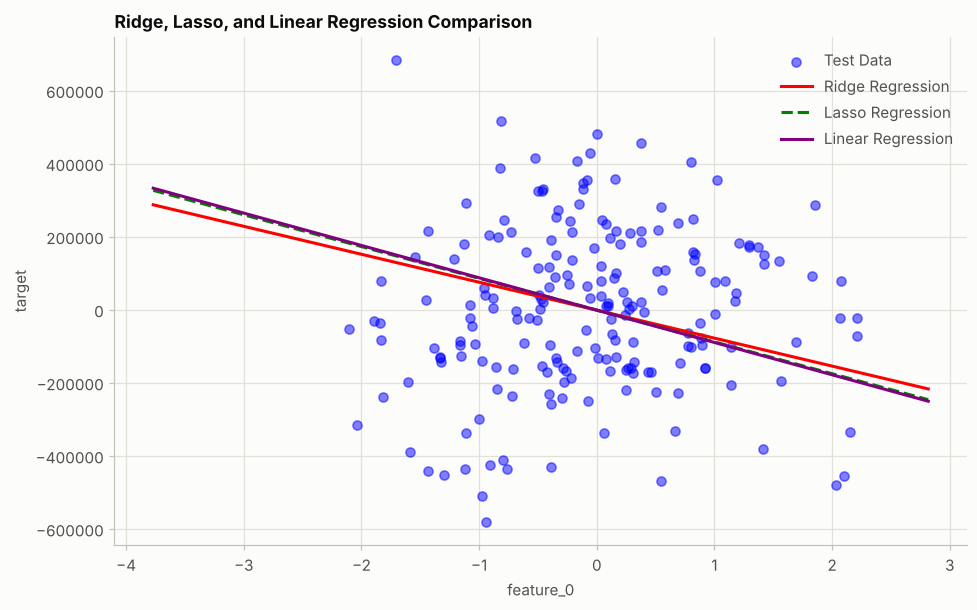

In [7]:
# BOOK CODE: Ridge and Lasso regression -- how to do it (pp. 100-103)
# Load libraries
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Create and fit Ridge regression model
ridge_model = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge_model.fit(X_train, y_train)

# Create and fit Lasso regression model with increased iterations and alpha
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Make predictions with both models
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate performance
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics for all models
metrics = {
    'Model': ['Ridge Regression', 'Lasso Regression', 'Linear Regression'],
    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_linear)
    ],
    'R-squared': [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_linear)
    ]
}

# Create DataFrame and sort by MSE
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format the numeric columns
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

display(metrics_df)

# Visualize the results (using feature_0 for visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')

# Sort the data for smooth line plots
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)

# Generate predictions for the line
y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.plot(X_line, y_line_ridge, color='red', label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linestyle='--', label='Lasso Regression')
plt.plot(X_line, y_line_linear, color='purple', label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()

**Output analysis.**

* **The ranking matches the book:** ridge first, then Lasso, then plain linear regression. All three $R^2$ values stay close to 0, for the reason found in recipe 1: the information about most of the target is no longer in the features.
* **Why the gains are so small.** On these unscaled features with a target in the hundreds of thousands, `alpha=1` for ridge and `alpha=10` for Lasso are weak penalties. Ridge's small improvement comes from stabilizing the collinear pairs.
* **The plotted lines** differ slightly in slope because each model gives `feature_0` a different coefficient. (The feature-name warnings of this listing have the same harmless cause as in recipe 1.) Extra (a) tunes `alpha` by cross-validation and shows how much regularization these data actually want.

In [8]:
# EXTRA: (a) Letting cross-validation choose alpha (standardized features, inside a pipeline)
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ridge_cv = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 50))).fit(X_train, y_train)
lasso_cv = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0, max_iter=20000)).fit(X_train, y_train)
tuned = pd.DataFrame({
    "alpha": [np.nan, ridge_cv[-1].alpha_, lasso_cv[-1].alpha_],
    "test R2": [linear_model.score(X_test, y_test), ridge_cv.score(X_test, y_test), lasso_cv.score(X_test, y_test)],
    "non-zero coefficients": [100, int((ridge_cv[-1].coef_ != 0).sum()), int((lasso_cv[-1].coef_ != 0).sum())],
}, index=["LinearRegression", "RidgeCV (standardized)", "LassoCV (standardized)"])
display(tuned.round(3))
kept = np.flatnonzero(lasso_cv[-1].coef_)
print("columns kept by Lasso:", kept.tolist())
print("surviving informative columns (0-49) among them:", sorted(int(c) for c in set(kept) & set(informative[informative < 50])))

,alpha,test R2,non-zero coefficients
LinearRegression,NaN,0.001,100
RidgeCV (standardized),372.759,0.143,100
LassoCV (standardized),9933.525,0.209,13


columns kept by Lasso: [0, 2, 3, 15, 21, 25, 32, 49, 55, 59, 71, 76, 91]
surviving informative columns (0-49) among them: [3, 21, 25]


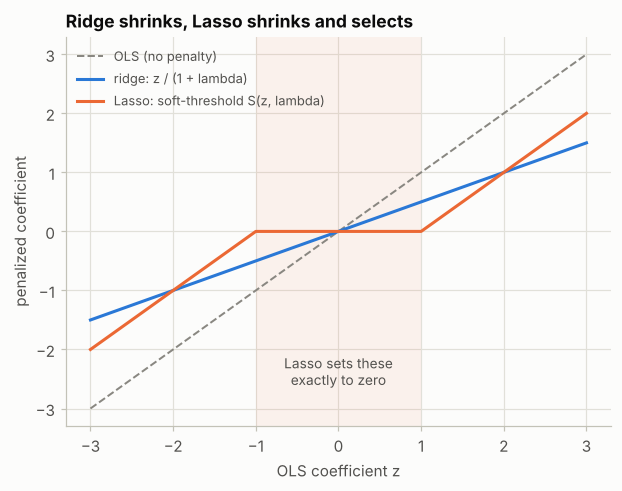

In [9]:
# EXTRA: (b) Shrinkage versus soft-thresholding -- what each penalty does to a single OLS coefficient
z = np.linspace(-3, 3, 601)           # the OLS estimate of one coefficient (orthonormal features)
lam = 1.0
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(z, z, color=MUTED, linestyle="--", linewidth=1.3, label="OLS (no penalty)")
ax.plot(z, z / (1 + lam), color=PALETTE[0], label="ridge: z / (1 + lambda)")
ax.plot(z, np.sign(z) * np.maximum(np.abs(z) - lam, 0), color=PALETTE[1], label="Lasso: soft-threshold S(z, lambda)")
ax.axvspan(-lam, lam, color=PALETTE[1], alpha=0.07, linewidth=0)
ax.text(0, -2.6, "Lasso sets these\nexactly to zero", ha="center", fontsize=9, color=INK_SOFT)
ax.set(xlabel="OLS coefficient z", ylabel="penalized coefficient", title="Ridge shrinks, Lasso shrinks and selects")
ax.legend(loc="upper left", fontsize=8.5)
plt.show()

**Output analysis.**

* **(a) Tuned penalties:**
  * With standardized features and `alpha` chosen by cross-validation, both models improve markedly over the book's settings. They are still far from a good fit, because most of the signal is gone.
  * `RidgeCV` picks a much stronger penalty than `alpha=1`, which mainly tames the collinear pairs.
  * `LassoCV` keeps only about a dozen of the 100 columns, including the three informative columns that survived the overwriting, and reaches the highest test $R^2$ of all.

  Regularization pays off once its strength is *tuned* rather than guessed, and once the features are on one scale so the penalty treats them equally.
* **(b) The two penalties:**
  * Ridge maps every OLS coefficient to a proportionally smaller one: a straight line through the origin, so it never reaches zero.
  * Lasso subtracts a fixed amount and clips at zero: every coefficient whose OLS value lies in the shaded band becomes exactly 0.

  This is the "feature selection" the book attributes to Lasso, in one picture.

---
## 3. ElasticNet and regularization

### Summary

* **ElasticNet** is a hybrid of ridge and Lasso:
  * `alpha` sets the overall strength of the regularization;
  * `l1_ratio` sets the mix between the Lasso and ridge penalties.

  It suits data with a mix of strongly correlated and uncorrelated features.
* **Getting ready:** `ElasticNet()` from `sklearn.linear_model`, with the dataset of recipe 1.
* **How to do it:**
  * Fit ElasticNet for every combination of seven `alpha` values (0.0001 to 100) and five `l1_ratio` values (0.1 to 0.9).
  * Draw a **coefficient path plot**: coefficient values against $\log_{10}(\alpha)$, one line per feature, one line style per `l1_ratio` (Figure 5.6).
  * Fit `ElasticNet(alpha=1.0, l1_ratio=0.5)` and add it to the metrics table. "You can see that its performance is better than our three previous models" (Figure 5.5).
* **Reading the path plot:**
  * As `alpha` grows, the coefficients get smaller, and some become exactly 0 (feature selection).
  * `l1_ratio = 0.1` behaves more like ridge (shrinking); `l1_ratio = 0.9` more like Lasso (eliminating).
  * Features whose coefficients resist shrinkage are the most important.
  * With 100 features the plot is hard to read; a smaller dataset would be clearer.
* **How it works:** the loss adds both penalties, $\alpha\big(\lambda_1\sum_j|\beta_j| + \lambda_2\sum_j\beta_j^2\big)$. An `l1_ratio` of 1 gives Lasso, 0 gives ridge, and values in between mix both.
* **There's more:** like Lasso, ElasticNet can set coefficients to exactly zero, which is useful for high-dimensional data.
* **Hands-on exercises:** vary `alpha` and `l1_ratio`, and plot predictions or coefficient paths.

### Theory: the ElasticNet penalty and the grouping effect

scikit-learn's `ElasticNet` minimizes, with $\rho$ = `l1_ratio`:

$$\frac{1}{2n}\lVert\mathbf{y} - \mathbf{X}\mathbf{w}\rVert_2^2 + \alpha\rho\,\lVert\mathbf{w}\rVert_1 + \frac{\alpha(1-\rho)}{2}\lVert\mathbf{w}\rVert_2^2 .$$

In the book's notation this means $\lambda_1 = \rho$ and $\lambda_2 = (1-\rho)/2$, on a loss scaled by $\frac{1}{2n}$. `Lasso` is the special case $\rho = 1$. For pure ridge, use `Ridge` rather than `l1_ratio=0`: coordinate descent is not reliable for very small `l1_ratio`.

* **Why combine the penalties?**
  * With strongly correlated features, Lasso picks one of them more or less arbitrarily, and the choice can flip between samples of the data.
  * The $L_2$ part makes the objective strictly convex and pulls correlated features towards **equal** coefficients — the *grouping effect* (Zou & Hastie, 2005; extra b).
  * When there are more features than observations ($p > n$), Lasso can select at most $n$ features. ElasticNet has no such limit.
* **Coefficient paths.** `lasso_path` and `enet_path` compute the whole path efficiently, starting from a large `alpha` (all coefficients 0) and decreasing it, re-using each solution as the starting point for the next ("warm starts"). This is how `LassoCV` and `ElasticNetCV` scan many `alpha` values quickly.
* **A precision.** Ridge never performs feature selection: its coefficients approach 0 as `alpha` grows but never reach it. Only penalties with an $L_1$ part (Lasso and ElasticNet with $\rho > 0$) produce exact zeros. The book's path-plot reading says ElasticNet performs feature selection "similar to both ridge and Lasso".

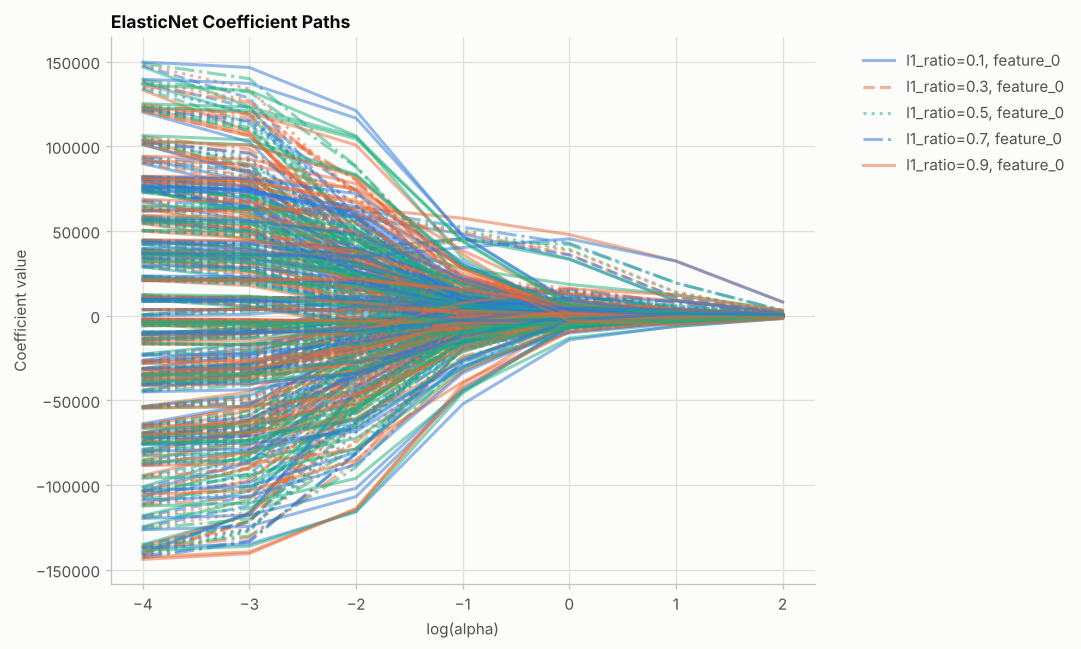

,Model,Mean Squared Error,R-squared
3,ElasticNet Regression,42634909074.06,0.14
0,Ridge Regression,47817487294.28,0.04
1,Lasso Regression,49482295964.55,0.01
2,Linear Regression,49712054061.09,0.00


In [10]:
# BOOK CODE: ElasticNet and regularization -- how to do it (pp. 105-107)
# Load libraries
from sklearn.linear_model import ElasticNet

# Create a range of alphas to test
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Store coefficients for plotting
coef_paths = []
labels = []

# Create and fit ElasticNet models with different parameters
plt.figure(figsize=(10, 6))

for l1_ratio in l1_ratios:
    coefs = []
    for alpha in alphas:
        # Create and fit ElasticNet model with increased max_iter and tol
        elastic_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=123,
                                 max_iter=10000, tol=1e-4)
        elastic_model.fit(X_train, y_train)
        coefs.append(elastic_model.coef_)

    # Convert coefficients to array and store
    coef_paths.append(np.array(coefs))

    # Plot coefficient paths
    for feature_idx in range(X_train.shape[1]):
        plt.plot(np.log10(alphas),
                np.array(coefs)[:, feature_idx],
                label=f'l1_ratio={l1_ratio}, feature_{feature_idx}' if feature_idx == 0 else "",
                alpha=0.5,
                linestyle=['solid', 'dashed', 'dotted', 'dashdot', '-'][l1_ratios.index(l1_ratio)])

plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Create a model with balanced l1_ratio and moderate alpha
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=123,
                          max_iter=10000, tol=1e-4)
elastic_model.fit(X_train, y_train)

# Calculate metrics
elastic_pred = elastic_model.predict(X_test)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

# Add ElasticNet results to metrics DataFrame
new_row = pd.DataFrame({
    'Model': ['ElasticNet Regression'],
    'Mean Squared Error': [elastic_mse],
    'R-squared': [elastic_r2]
})

# Remove any existing ElasticNet entries before concatenating
metrics_df = metrics_df[~metrics_df['Model'].str.contains('ElasticNet')]

# Convert string values back to float for sorting
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].astype(float)
metrics_df['R-squared'] = metrics_df['R-squared'].astype(float)

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Sort the metrics DataFrame by Mean Squared Error
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format the numeric columns for display
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

# Display updated metrics
display(metrics_df)

**Output analysis.**

* **The path plot** has 500 lines: 100 features times five `l1_ratio` values. As the book admits, it is hard to read. The general shape is visible:
  * at $\alpha \le 0.01$ the coefficients spread widely (up to about ±150,000 on this target scale);
  * between $\alpha = 0.01$ and $\alpha = 1$ most of them collapse towards zero;
  * by $\alpha = 100$ all of them are close to zero.

  The `l1_ratio` values cannot be told apart, for two reasons. The fifth line style `'-'` is the same as the first, `'solid'`, so `l1_ratio=0.1` and `l1_ratio=0.9` are drawn identically. The colours cycle over the 100 features rather than encoding the ratio. Extra (a) draws the same kind of plot on a 10-feature dataset where every path can be followed.
* **The metrics table confirms the book's claim:** ElasticNet with `alpha=1.0, l1_ratio=0.5` has the lowest MSE and the highest $R^2$ of the four models. The reason is the strength of the penalty, not the mix. On this loss scale, `alpha=1` with half of it in the $L_2$ part is a far stronger ridge-like penalty than `Ridge(alpha=1)`, which brings ElasticNet close to the cross-validated ridge of recipe 2.

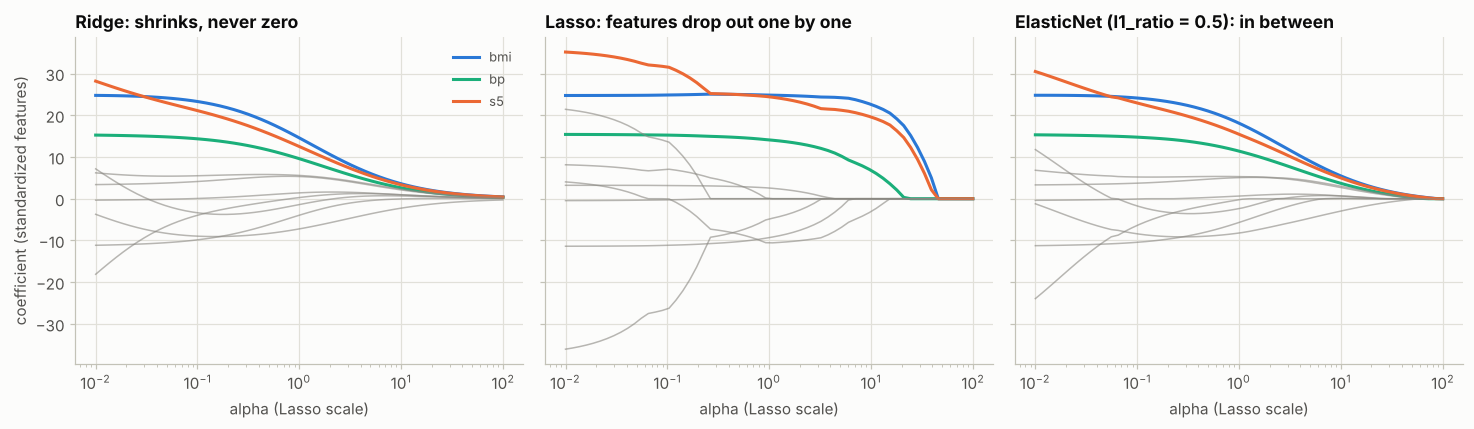

alpha ~  0.1: non-zero coefficients -- ridge 10, Lasso 10, ElasticNet 10
alpha ~    1: non-zero coefficients -- ridge 10, Lasso 8, ElasticNet 10
alpha ~   10: non-zero coefficients -- ridge 10, Lasso 4, ElasticNet 9
alpha ~   40: non-zero coefficients -- ridge 10, Lasso 2, ElasticNet 6


In [11]:
# EXTRA: (a) A readable coefficient path -- the diabetes data (10 standardized features)
from sklearn.datasets import load_diabetes
from sklearn.linear_model import enet_path, lasso_path

diabetes = load_diabetes()
Xd = StandardScaler().fit_transform(diabetes.data)
yd = diabetes.target - diabetes.target.mean()
path_alphas = np.logspace(-2, 2, 60)
highlight = {"bmi": PALETTE[0], "s5": PALETTE[1], "bp": PALETTE[2]}

ridge_coefs = np.array([Ridge(alpha=a * len(yd)).fit(Xd, yd).coef_ for a in path_alphas]).T   # alpha on Lasso's 1/(2n) scale
lasso_alphas, lasso_coefs, _ = lasso_path(Xd, yd, alphas=path_alphas)          # returned in decreasing order of alpha
enet_alphas, enet_coefs, _ = enet_path(Xd, yd, alphas=path_alphas, l1_ratio=0.5)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True)
for ax, a_grid, coefs, title in [(axes[0], path_alphas, ridge_coefs, "Ridge: shrinks, never zero"),
                                 (axes[1], lasso_alphas, lasso_coefs, "Lasso: features drop out one by one"),
                                 (axes[2], enet_alphas, enet_coefs, "ElasticNet (l1_ratio = 0.5): in between")]:
    for j, name in enumerate(diabetes.feature_names):
        ax.plot(a_grid, coefs[j], color=highlight.get(name, MUTED), linewidth=2 if name in highlight else 1,
                alpha=1 if name in highlight else 0.6, label=name if name in highlight else None)
    ax.set(xscale="log", xlabel="alpha (Lasso scale)", title=title)
axes[0].set_ylabel("coefficient (standardized features)")
axes[0].legend(loc="upper right", fontsize=8.5)
plt.tight_layout()
plt.show()
for a in [0.1, 1, 10, 40]:
    kr, kl, ke = (np.argmin(np.abs(grid - a)) for grid in (path_alphas, lasso_alphas, enet_alphas))
    print(f"alpha ~ {a:>4}: non-zero coefficients -- ridge {np.sum(ridge_coefs[:, kr] != 0)}, "
          f"Lasso {np.sum(lasso_coefs[:, kl] != 0)}, ElasticNet {np.sum(enet_coefs[:, ke] != 0)}")

In [12]:
# EXTRA: (b) The grouping effect -- two almost identical features that matter equally
rng = np.random.default_rng(1)
n = 200
shared = rng.normal(size=n)
x_a = shared + rng.normal(0, 0.02, n)                    # two near-copies (correlation about 0.9995)
x_b = shared + rng.normal(0, 0.02, n)
X_group = np.column_stack([x_a, x_b, rng.normal(size=(n, 3))])   # plus three irrelevant features
y_group = x_a + x_b + rng.normal(0, 0.5, n)              # both copies matter equally
models = {"OLS": LinearRegression(), "Ridge (alpha=10)": Ridge(alpha=10),
          "Lasso (alpha=0.2)": Lasso(alpha=0.2), "ElasticNet (alpha=0.2, l1_ratio=0.5)": ElasticNet(alpha=0.2, l1_ratio=0.5)}
display(pd.DataFrame({name: m.fit(X_group, y_group).coef_ for name, m in models.items()},
                     index=["copy A", "copy B", "noise 1", "noise 2", "noise 3"]).T.round(3))

,copy A,copy B,noise 1,noise 2,noise 3
OLS,1.255,0.743,0.009,-0.066,-0.036
Ridge (alpha=10),0.970,0.968,0.003,-0.071,-0.030
Lasso (alpha=0.2),1.149,0.624,-0.000,-0.000,-0.000
"ElasticNet (alpha=0.2, l1_ratio=0.5)",0.892,0.892,-0.000,-0.002,-0.000


**Output analysis.**

* **(a) Paths you can read:**
  * **Ridge:** all ten coefficients shrink smoothly towards zero, and none reaches it.
  * **Lasso:** features drop out one by one as `alpha` grows. Body-mass index (`bmi`), the serum measurement `s5` and blood pressure (`bp`) are the last to survive, so they are the most important predictors of disease progression.
  * **ElasticNet** keeps features longer than Lasso and shrinks them more gently.

  The printed counts make the difference exact: ridge keeps all ten coefficients at every `alpha`, while Lasso drops more and more of them.
* **(b) The grouping effect:**
  * OLS splits the weight between the two near-identical copies unevenly, by chance.
  * Lasso also splits it unevenly, because for $L_1$ any split with the same total costs the same, so the data's noise decides.
  * Ridge and ElasticNet give the two copies **equal** coefficients, because the squared penalty is smallest when the weight is shared.

  Lasso and ElasticNet also set the three irrelevant features to (almost) exactly zero, while ridge leaves them small but non-zero. ElasticNet combines both behaviours, which is why it is preferred when correlated features should be kept or dropped *together*.

---
## 4. Regularization theory and practice

### Summary

* Regularization is used in almost every real-world application of machine learning. It prevents overfitting and improves **generalization**, by adding a penalty term to the loss function that discourages the model from becoming too complex or relying too heavily on specific features. The model then captures the underlying patterns rather than memorizing noise.
* The idea is a balance between **model complexity and goodness of fit**. An unregularized model can reach near-perfect training performance with an overly complex function and then fail on new data. Regularization constrains the parameters, "effectively shrinking them toward 0 – or, in ML parlance, encouraging sparsity".
* **Model complexity** is a model's capacity to fit a wide variety of functions.
* **Types of regularization:**
  * $L_1$ (Lasso): penalizes the absolute values of the coefficients and can set some exactly to 0, performing feature selection.
  * $L_2$ (ridge): penalizes their squares; it discourages large coefficients but keeps every feature.
  * ElasticNet: combines both, and is useful with correlated features or when there are more predictors than observations.
* **The bias–variance trade-off:** regularization increases bias slightly but reduces variance significantly. The goal is the level of regularization that minimizes the prediction error on unseen data.
* **There's more:** group Lasso for selecting groups of features, and Bayesian regression with prior distributions on the coefficients.

> The book gives no code for this recipe. The extras draw the geometry behind the penalties and measure the bias–variance trade-off of ridge.

### Theory: three views of the same penalty

**1. Constraints.** Minimizing $\text{RSS} + \alpha\lVert\mathbf{w}\rVert_q$ is equivalent to minimizing the RSS subject to $\lVert\mathbf{w}\rVert_q \le t$, for a budget $t$ that shrinks as $\alpha$ grows. The solution is the point where the elliptical contours of the RSS first touch the constraint region:

* the $L_2$ region is a disc, and the contact point is almost never on an axis;
* the $L_1$ region is a diamond with **corners on the axes**, and the expanding ellipses usually hit a corner first, where some coefficients are exactly zero (extra a).

The same unit balls appeared in Chapter 4's distance metrics.

**2. Bias and variance.** For a new point, the expected squared error of a model fitted on a random training set splits into three parts:

$$\mathbb{E}\big[(y - \hat f(\mathbf{x}))^2\big] = \underbrace{\big(f(\mathbf{x}) - \mathbb{E}\hat f(\mathbf{x})\big)^2}_{\text{bias}^2} + \underbrace{\operatorname{Var}\hat f(\mathbf{x})}_{\text{variance}} + \sigma^2 .$$

Increasing $\alpha$ moves the fit towards a simpler function (more bias) and makes it less sensitive to the particular training sample (less variance). The test error is therefore typically **U-shaped in $\alpha$**, and cross-validation finds the bottom of the U (extra b).

For ridge, the *effective degrees of freedom* $\mathrm{df}(\alpha) = \sum_j \frac{d_j^2}{d_j^2 + \alpha}$ fall smoothly from $p$ (at $\alpha = 0$) towards 0, a continuous measure of model complexity.

**3. Prior beliefs.** Penalized least squares is the *maximum a posteriori* estimate of a Bayesian model:

* ridge corresponds to a Gaussian prior on each coefficient;
* Lasso corresponds to a Laplace prior, which has a sharp peak at zero and so favours exact zeros.

scikit-learn's `BayesianRidge` and `ARDRegression` estimate the strength of the prior from the data instead of by cross-validation. This is the "Bayesian regression" of the book's "There's more". Group Lasso itself is not in scikit-learn; `MultiTaskLasso` applies a related group penalty across several targets.

**A precision.** "Encouraging sparsity" (exact zeros) is a property of $L_1$ penalties only. $L_2$ shrinks every coefficient towards zero but leaves all of them non-zero.

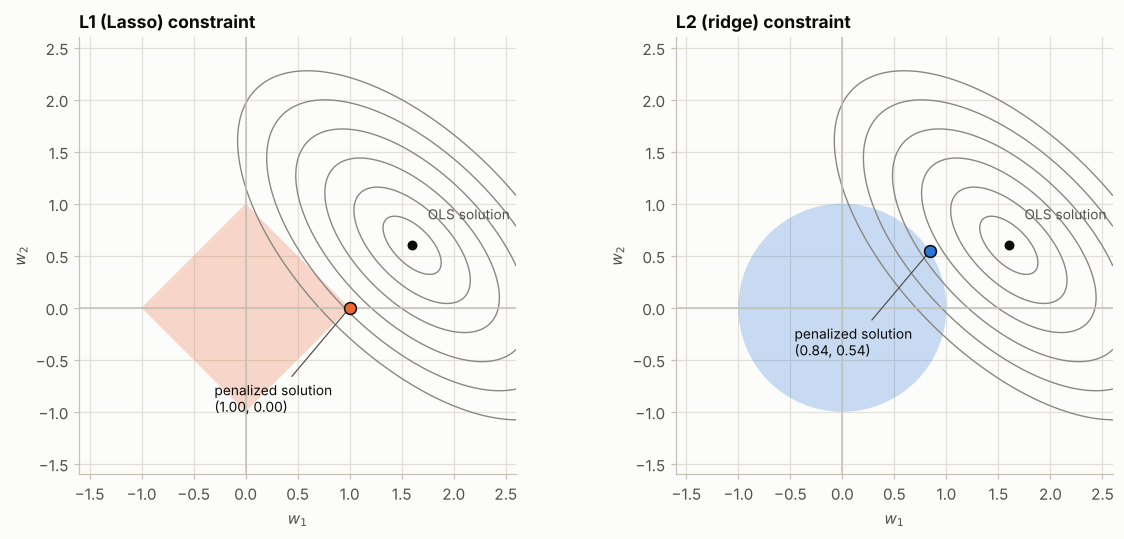

In [13]:
# EXTRA: (a) Why the L1 penalty produces zeros -- the constraint regions and the contours of the loss
w1, w2 = np.meshgrid(np.linspace(-1.6, 2.6, 400), np.linspace(-1.6, 2.6, 400))
ols = np.array([1.6, 0.6])                                   # the unconstrained (OLS) solution
H = np.array([[1.0, 0.6], [0.6, 1.0]])                       # curvature of the loss (correlated features)
diff = np.stack([w1 - ols[0], w2 - ols[1]], axis=-1)
rss = np.einsum("...i,ij,...j->...", diff, H, diff)

def constrained_minimum(norm, budget=1.0):
    """Brute-force search on the boundary of the constraint region for the point of lowest loss."""
    theta = np.linspace(0, 2 * np.pi, 20001)
    if norm == 1:
        pts = np.column_stack([np.cos(theta), np.sin(theta)])
        pts = budget * pts / np.abs(pts).sum(axis=1, keepdims=True)
    else:
        pts = budget * np.column_stack([np.cos(theta), np.sin(theta)])
    d = pts - ols
    return pts[np.argmin(np.einsum("ni,ij,nj->n", d, H, d))]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, norm, color, name in [(axes[0], 1, PALETTE[1], "L1 (Lasso) constraint"), (axes[1], 2, PALETTE[0], "L2 (ridge) constraint")]:
    ax.contour(w1, w2, rss, levels=[0.05, 0.2, 0.45, 0.8, 1.25, 1.8], colors=MUTED, linewidths=0.9)
    if norm == 1:
        ax.fill([1, 0, -1, 0], [0, 1, 0, -1], color=color, alpha=0.25, linewidth=0)
    else:
        ax.add_patch(plt.Circle((0, 0), 1, color=color, alpha=0.25, linewidth=0))
    best = constrained_minimum(norm)
    ax.scatter(*ols, color=INK, s=30, zorder=3)
    ax.annotate("OLS solution", ols, xytext=(ols[0] + 0.15, ols[1] + 0.25), fontsize=9, color=INK_SOFT)
    ax.scatter(*best, color=color, s=60, edgecolor=INK, zorder=4)
    ax.annotate(f"penalized solution\n({best[0]:.2f}, {best[1]:.2f})", best, xytext=(best[0] - 1.3, best[1] - 1.0),
                fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=INK_SOFT, lw=0.8))
    ax.axhline(0, color=AXIS, linewidth=1); ax.axvline(0, color=AXIS, linewidth=1)
    ax.set(aspect="equal", xlim=(-1.6, 2.6), ylim=(-1.6, 2.6), xlabel="$w_1$", ylabel="$w_2$", title=name)
plt.tight_layout()
plt.show()

alpha,1.000000e-08,1.000000e-07,1.000000e-06,1.000000e-05,1.000000e-04,1.000000e-03,1.000000e-02,1.000000e-01,1.000000e+00,1.000000e+01,1.000000e+02
bias^2,0.002,0.001,0.001,0.001,0.000,0.003,0.015,0.032,0.095,0.123,0.302
variance,20.214,14.345,9.759,3.279,0.817,0.199,0.185,0.057,0.091,0.024,0.047
expected test MSE,20.306,14.437,9.849,3.369,0.908,0.292,0.290,0.179,0.276,0.237,0.439


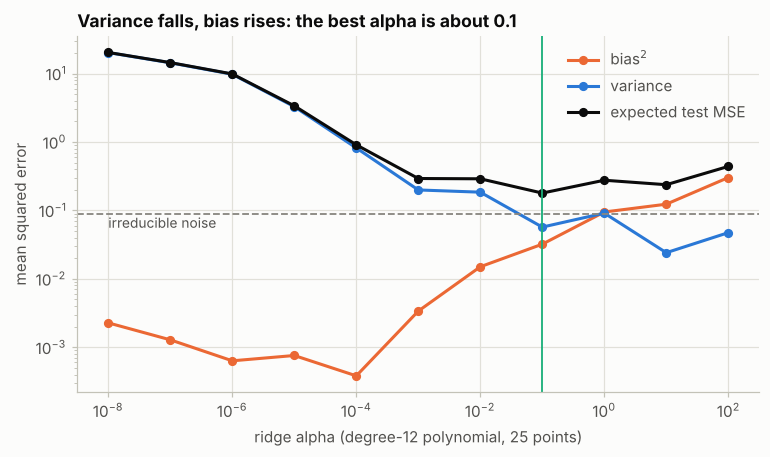

In [14]:
# EXTRA: (b) The bias-variance trade-off of ridge, measured over 200 random training sets
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.default_rng(0)
x_grid = np.linspace(0, 1, 400)
f_true = np.sin(2 * np.pi * x_grid)                          # the true function
noise_sd = 0.3
ridge_alphas = np.logspace(-8, 2, 11)
preds = np.zeros((len(ridge_alphas), 200, len(x_grid)))
for r in range(200):                                         # 200 training sets of 25 noisy points each
    x_s = rng.uniform(0, 1, 25)
    y_s = np.sin(2 * np.pi * x_s) + rng.normal(0, noise_sd, 25)
    for i, a in enumerate(ridge_alphas):
        model = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(), Ridge(alpha=a))
        preds[i, r] = model.fit(x_s.reshape(-1, 1), y_s).predict(x_grid.reshape(-1, 1))
bias2 = ((preds.mean(axis=1) - f_true) ** 2).mean(axis=1)
variance = preds.var(axis=1).mean(axis=1)
bv = pd.DataFrame({"alpha": ridge_alphas, "bias^2": bias2, "variance": variance,
                   "expected test MSE": bias2 + variance + noise_sd ** 2})
display(bv.set_index("alpha").T.round(3))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ridge_alphas, bv["bias^2"], color=PALETTE[1], marker="o", markersize=5, label="bias$^2$")
ax.plot(ridge_alphas, bv["variance"], color=PALETTE[0], marker="o", markersize=5, label="variance")
ax.plot(ridge_alphas, bv["expected test MSE"], color=INK, marker="o", markersize=5, label="expected test MSE")
ax.axhline(noise_sd ** 2, color=MUTED, linestyle="--", linewidth=1.2)
ax.text(ridge_alphas[0], noise_sd ** 2 * 0.62, "irreducible noise", fontsize=9, color=INK_SOFT)
best_alpha = ridge_alphas[np.argmin(bv["expected test MSE"])]
ax.axvline(best_alpha, color=PALETTE[2], linewidth=1.2)
ax.set(xscale="log", yscale="log", xlabel="ridge alpha (degree-12 polynomial, 25 points)", ylabel="mean squared error",
       title=f"Variance falls, bias rises: the best alpha is about {best_alpha:g}")
ax.legend(loc="upper right")
plt.show()

**Output analysis.**

* **(a) The geometry:**
  * The loss contours are ellipses around the OLS solution.
  * The $L_1$ diamond is first touched at its corner on the $w_1$ axis, so the penalized solution has $w_2 = 0$ *exactly*.
  * The $L_2$ disc is touched at a point where both coefficients are non-zero, just smaller.

  The corners are the whole reason Lasso selects features: in higher dimensions the $L_1$ ball has even more corners and edges where several coordinates are zero at once.
* **(b) Bias and variance, measured:**
  * With almost no penalty, a degree-12 polynomial fitted to 25 points has a tiny bias but a huge variance: its shape depends wildly on which 25 points were drawn.
  * Increasing `alpha` cuts the variance by orders of magnitude while the bias grows only slowly.
  * The expected test error is lowest at a moderate penalty and rises again for large `alpha`, where the model becomes too stiff to follow the sine (bias dominates).

  This is the U-shape the book describes in words. Cross-validation, as with `RidgeCV` in recipe 2, is the practical way to find the bottom of it.

---
## 5. Regression and regularization (polynomial regression and splines)

### Summary

* Polynomial regression and spline interpolation extend linear regression to non-linear ("exponential or curvilinear") relationships.
* **Getting ready:** a new dataset of 1,000 points, with `np.random.seed(123)`:
  * $x$ uniform on $[-50, 50]$;
  * target $y = 2x + 27\sin(x/8) + \text{noise}$, with noise standard deviation 4;
  * plotted with seaborn (Figure 5.7).

  The text says the data are made with `make_regression()` plus a sine wave and an exponential function; the code uses neither `make_regression()` nor an exponential.
* **How to do it** (polynomials):
  * For degrees 1 to 5, transform $x$ with `PolynomialFeatures`, split 80/20, fit `LinearRegression`, and report the test MSE and $R^2$.
  * Plot the five fitted curves and the residuals of the best degree by $R^2$ (Figure 5.8, where the best was the fifth degree).
  * The book's caution: polynomial regression "can seem like magic", but it can overfit. Looking only at MSE and $R^2$ during model selection is problematic.
* **Spline interpolation:**
  * Piecewise polynomials joined smoothly at **knots**.
  * `SplineTransformer(n_knots=k, degree=3)` with 3, 5 and 7 knots, followed by `LinearRegression` in a pipeline.
  * The MSE and $R^2$ are computed on all the data (Figures 5.9 and 5.10): "As the number of knots increases … our MSE decreases, indicating a better model fit."
* **How it works:**
  * Polynomial regression fits $y = \beta_0 + \beta_1 x + \dots + \beta_d x^d + \epsilon$ — still linear in the coefficients.
  * Splines fit piecewise polynomials that join smoothly at the knots.
* **There's more:** B-splines and natural splines for more sophisticated non-linear modelling.
* **Hands-on exercises:** fit both methods and compare their metrics.

### Theory: linear models on non-linear features

Both methods replace $x$ by a set of **basis functions** $\phi_1(x), \dots, \phi_m(x)$ and fit an ordinary linear model on them:

$$y = \beta_0 + \sum_{k=1}^{m} \beta_k\,\phi_k(x) + \epsilon .$$

The model is non-linear in $x$ but linear in the coefficients, so OLS, ridge and Lasso all apply unchanged.

* **Polynomial basis** (`PolynomialFeatures`): $\phi_k(x) = x^k$.
  * Each basis function is global — changing one coefficient bends the curve everywhere.
  * High degrees oscillate wildly near the edges of the data (Runge's phenomenon).
  * Raw powers are **badly scaled**: on $[-50, 50]$, $x^5$ reaches $3 \times 10^8$ while $x$ stays below 50. Standardizing $x$ first, or using an orthogonal polynomial basis, avoids numerical trouble (extra a).
* **Spline basis** (`SplineTransformer`):
  * A cubic spline is a piecewise cubic polynomial whose value and first two derivatives are continuous at the knots.
  * scikit-learn builds it from **B-splines**: `n_knots + degree - 1` basis functions per feature, each non-zero only between a few neighbouring knots. That local support keeps the problem well conditioned and lets the curve bend in one region without disturbing the rest.
  * Options: knots `"uniform"` (default) or at `"quantile"` positions; beyond the data the default `extrapolation="constant"` holds the boundary value.
* **Interpolation versus regression.** Strictly, an *interpolating* spline passes through every data point. What the recipe fits is a **regression spline**: a least-squares curve that smooths the noise. That is exactly what one wants for noisy data.
* **Choosing the complexity.** The degree or the number of knots is a hyperparameter like `alpha`. Training error always falls as the basis grows, so only held-out error (cross-validation) can choose it (extra b).

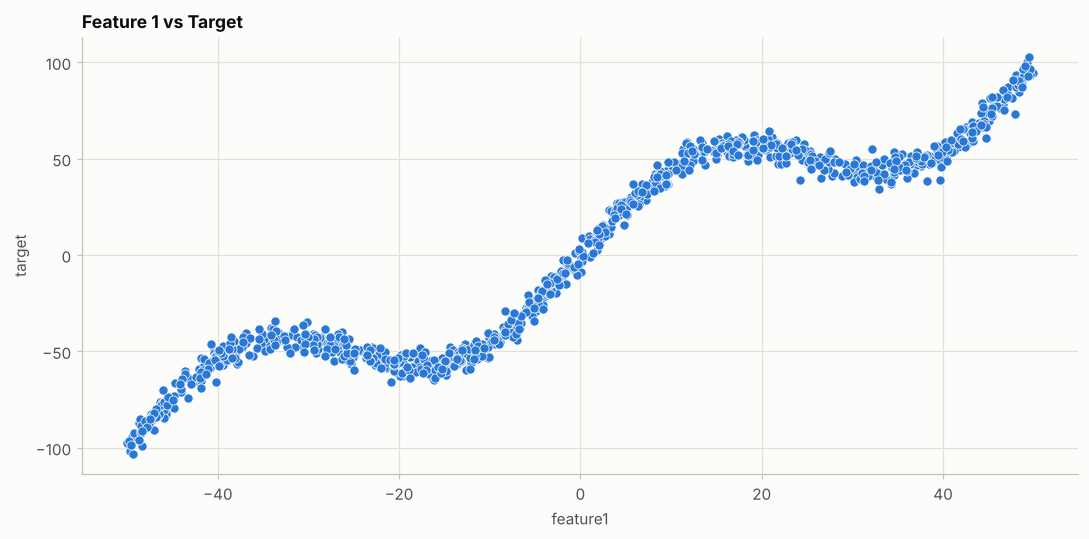

In [15]:
# BOOK CODE: Regression and regularization -- getting ready (pp. 112-113)
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create synthetic dataset with non-linear relationships
np.random.seed(123)
n_samples = 1000
X = np.random.uniform(-50, 50, (n_samples, 1))

# Create target with non-linear components:
y = (2 * X[:, 0]  # linear component
     + 27 * np.sin(X[:, 0] / 8)
     + np.random.normal(0, 4, n_samples))  # noise

# Create DataFrame
data = pd.DataFrame(X, columns=['feature1'])
data['target'] = y

# Create plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()


Model Performance Metrics:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5 811.070884 0.721464


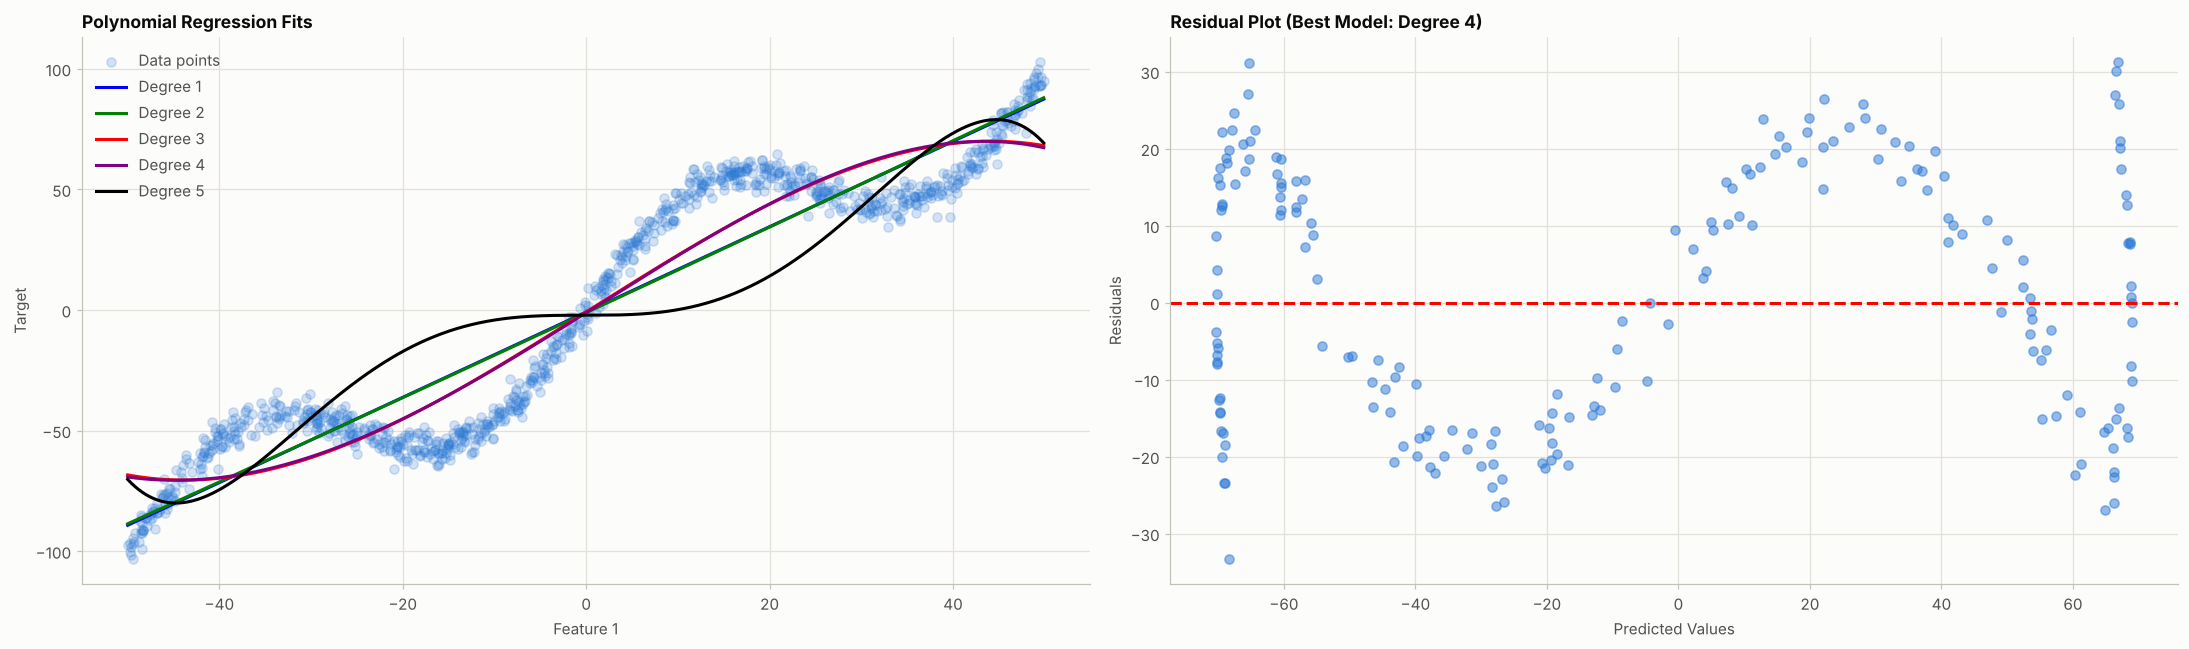

In [16]:
# BOOK CODE: Regression and regularization -- polynomial regression (pp. 114-116)
# Load libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Use the synthetic dataset created above
X = data[['feature1']]
y = data['target']

# Create a list of polynomial degrees to try
degrees = [1, 2, 3, 4, 5]
results = []

# Try different polynomial degrees
for degree in degrees:
    # Transform features to polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=123)

    # Create and fit Linear Regression model on polynomial features
    poly_model = LinearRegression()
    poly_model.fit(X_train, y_train)

    # Make predictions
    y_pred = poly_model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'Degree': degree,
        'MSE': mse,
        'R2': r2
    })

# Create DataFrame of results
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df.to_string(index=False))

# Create visualization of different polynomial fits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot data and polynomial fits
ax1.scatter(X['feature1'], y, alpha=0.2, label='Data points')

# Generate points for smooth curve plotting
X_plot = np.linspace(X['feature1'].min(), X['feature1'].max(), 1000).reshape(-1, 1)

colors = ['blue', 'green', 'red', 'purple', 'black']
for degree, color in zip(degrees, colors):
    poly = PolynomialFeatures(degree=degree)
    X_plot_poly = poly.fit_transform(X_plot)

    model = LinearRegression()
    model.fit(poly.fit_transform(X), y)
    y_plot = model.predict(X_plot_poly)

    ax1.plot(X_plot, y_plot, label=f'Degree {degree}', color=color, linewidth=2)

ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression Fits')
ax1.legend(loc='upper left')

# Plot residuals for best performing model (based on R2)
best_degree = results_df.loc[results_df['R2'].idxmax(), 'Degree']
best_poly = PolynomialFeatures(degree=best_degree)
X_poly_best = best_poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly_best, y, test_size=0.2, random_state=123)

best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

ax2.scatter(y_pred, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residual Plot (Best Model: Degree {best_degree})')

plt.tight_layout()
plt.show()

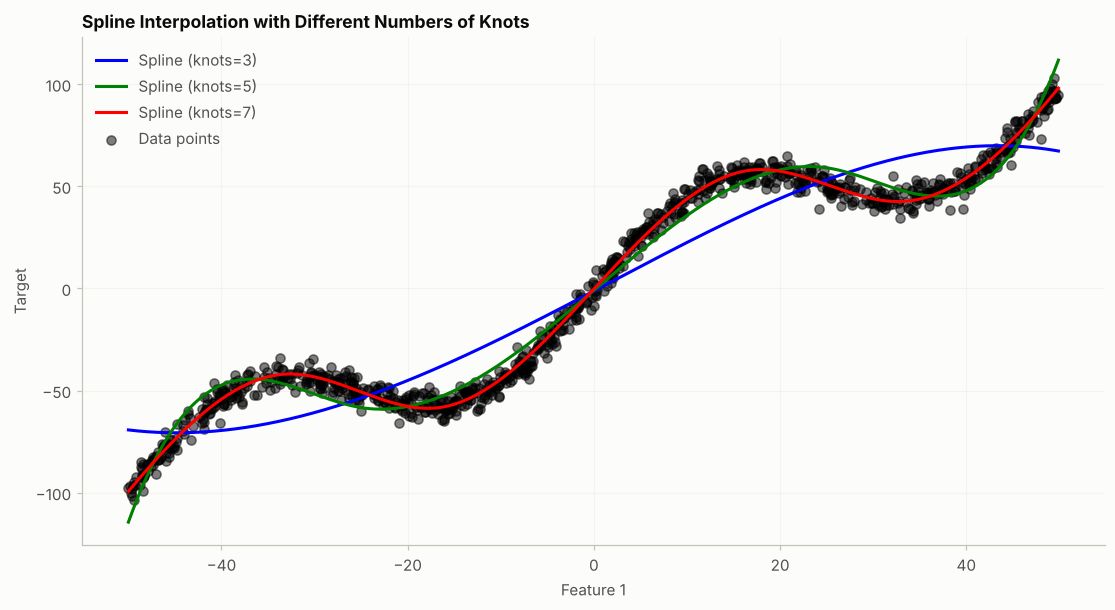

,Number of Knots,MSE,R-squared
0,3,274.267019,0.904652
1,5,55.347798,0.980759
2,7,15.502097,0.994611


In [17]:
# BOOK CODE: Regression and regularization -- spline interpolation (pp. 117-119)
# Load libraries
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Create a spline transformer with different degrees of freedom
n_knots = [3, 5, 7]  # Different numbers of knots to try
plt.figure(figsize=(12, 6))

# Create lists to store metrics
mse_scores = []
r2_scores = []

for n_knot, color in zip(n_knots, colors[:len(n_knots)]):
    # Create and fit spline transformer
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    model = make_pipeline(spline, LinearRegression())
    model.fit(X, y)

    # Generate predictions
    y_pred = model.predict(X_plot)
    y_pred_train = model.predict(X)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred_train)
    r2 = r2_score(y, y_pred_train)
    mse_scores.append(mse)
    r2_scores.append(r2)

    # Plot the results
    plt.plot(X_plot, y_pred,
             label=f'Spline (knots={n_knot})',
             color=color,
             linewidth=2)

# Plot original data points
plt.scatter(X, y, color='black', alpha=0.5, label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Create and display metrics DataFrame
metrics_df = pd.DataFrame({
    'Number of Knots': n_knots,
    'MSE': mse_scores,
    'R-squared': r2_scores
})
display(metrics_df)

**Output analysis.**

* **The data** follow a rising line with two waves of a sine on top, plus a little noise (Figure 5.7).
* **Polynomials — a result that differs from the book:**
  * Degrees 1 and 2 give the same test error, and so do degrees 3 and 4. The target is an odd function plus noise, so the even powers add almost nothing.
  * **Degree 5 is much worse** here ($R^2 \approx 0.72$), while the book found it the best (Figure 5.8). This is not overfitting: degree 5 is worse even on its *training* data, which is impossible for nested least-squares fits.
  * The cause is a change in scikit-learn 1.9. `LinearRegression`'s `tol` parameter (default `1e-6`) is now used as the cut-off for small singular values on dense data. The raw powers $x^0 \dots x^5$ span about nine orders of magnitude, so the solver treats the weakest direction as numerical noise and drops it. Extra (a) shows the rank, and two fixes.
  * As a consequence, the residual plot shows degree 4, the best by $R^2$ in this run. Its residuals still contain a clear wave: the polynomial has not captured the sine.
* **The polynomial curves** confirm it: none of the degrees 1–5 follows both waves of the sine.
* **Splines:**
  * With 3 knots the spline is barely more flexible than a cubic.
  * With 5 knots it follows the waves roughly.
  * With 7 knots it tracks them closely. Its training MSE approaches the noise variance ($4^2 = 16$), the lowest error any model can reach on average.

  The book's conclusion (more knots, lower MSE) holds for this range. But these MSE values are measured on the data used for fitting, and with enough knots the training MSE would keep falling while the fit started to chase noise. Extra (b) measures the held-out error. (This listing fits on a DataFrame and predicts from an array, the reverse of recipe 1; its feature-name warnings are silenced too.)

In [18]:
# EXTRA: (a) The degree-5 failure -- a numerical cut-off, not overfitting
X_poly5 = PolynomialFeatures(degree=5).fit_transform(X)
Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_poly5, y, test_size=0.2, random_state=123)
rows = []
for name, model in [("LinearRegression() on raw powers (the book's code)", LinearRegression()),
                    ("LinearRegression(tol=1e-10) on raw powers", LinearRegression(tol=1e-10)),
                    ("standardize x, then PolynomialFeatures(5)", None)]:
    if model is None:
        model = make_pipeline(StandardScaler(), PolynomialFeatures(degree=5), LinearRegression())
        model.fit(X.loc[yp_train.index], yp_train)
        tr, te, rank = model.score(X.loc[yp_train.index], yp_train), model.score(X.loc[yp_test.index], yp_test), model[-1].rank_
    else:
        model.fit(Xp_train, yp_train)
        tr, te, rank = model.score(Xp_train, yp_train), model.score(Xp_test, yp_test), model.rank_
    rows.append((name, rank, tr, te))
display(pd.DataFrame(rows, columns=["degree-5 model", "rank found by the solver", "training R2", "test R2"])
        .set_index("degree-5 model").round(4))
print(f"largest / smallest column scale of the raw powers: {np.abs(X_poly5).max(axis=0).max():.1e} / 1")

,rank found by the solver,training R2,test R2
degree-5 model,,,
LinearRegression() on raw powers (the book's code),4,0.6979,0.7215
LinearRegression(tol=1e-10) on raw powers,5,0.9837,0.9834
"standardize x, then PolynomialFeatures(5)",5,0.9837,0.9834


largest / smallest column scale of the raw powers: 3.1e+08 / 1


degree,1,3,5,7,9,11,13,15,20
polynomial CV MSE,337.94,276.54,47.95,15.83,15.0,15.11,15.15,15.15,15.96


knots,3,5,7,10,15,20,30,50,80
spline training MSE,274.27,55.35,15.50,14.73,14.65,14.61,14.48,14.10,13.35
spline CV MSE,278.43,56.34,15.72,15.02,15.13,15.27,15.43,15.75,16.08


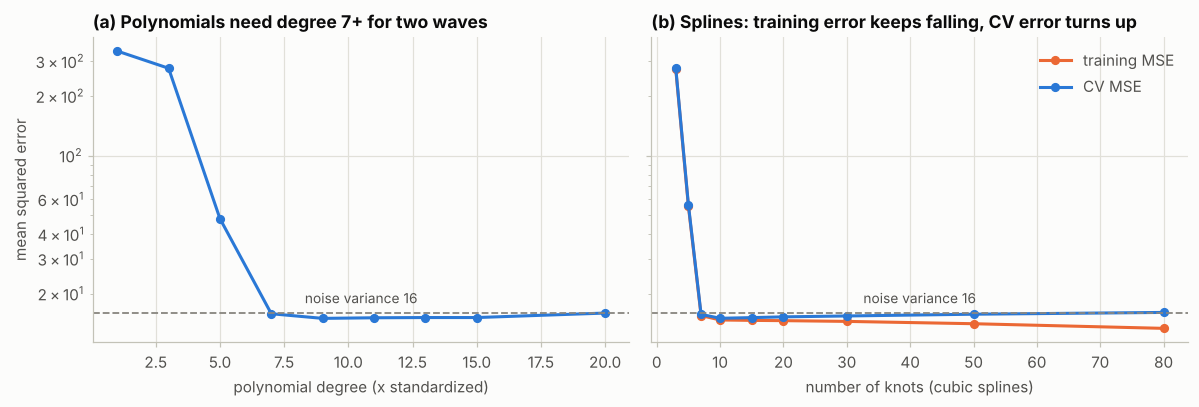

In [19]:
# EXTRA: (b) Choosing the degree and the number of knots by cross-validation
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_mse = lambda model: -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
poly_degrees = [1, 3, 5, 7, 9, 11, 13, 15, 20]
knot_counts = [3, 5, 7, 10, 15, 20, 30, 50, 80]
poly_cv = [cv_mse(make_pipeline(StandardScaler(), PolynomialFeatures(d), LinearRegression())) for d in poly_degrees]
spline_cv = [cv_mse(make_pipeline(SplineTransformer(n_knots=k, degree=3), LinearRegression())) for k in knot_counts]
spline_train = [mean_squared_error(y, make_pipeline(SplineTransformer(n_knots=k, degree=3), LinearRegression()).fit(X, y).predict(X))
                for k in knot_counts]
display(pd.DataFrame({"degree": poly_degrees, "polynomial CV MSE": poly_cv}).set_index("degree").T.round(2))
display(pd.DataFrame({"knots": knot_counts, "spline training MSE": spline_train, "spline CV MSE": spline_cv})
        .set_index("knots").T.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].plot(poly_degrees, poly_cv, color=PALETTE[0], marker="o", markersize=5, label="CV MSE")
axes[0].set(xlabel="polynomial degree (x standardized)", ylabel="mean squared error", yscale="log",
            title="(a) Polynomials need degree 7+ for two waves")
axes[1].plot(knot_counts, spline_train, color=PALETTE[1], marker="o", markersize=5, label="training MSE")
axes[1].plot(knot_counts, spline_cv, color=PALETTE[0], marker="o", markersize=5, label="CV MSE")
axes[1].set(xlabel="number of knots (cubic splines)", title="(b) Splines: training error keeps falling, CV error turns up")
for ax in axes:
    ax.axhline(16, color=MUTED, linestyle="--", linewidth=1.2)
    ax.text(np.mean(ax.get_xlim()), 16 * 1.12, "noise variance 16", ha="center", fontsize=9, color=INK_SOFT)
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

**Output analysis.**

* **(a) The degree-5 fit, diagnosed:**
  * With the default `tol`, the solver reports rank 4 for 5 non-constant columns: one direction was cut off, and the training $R^2$ collapses together with the test $R^2$.
  * Tightening the cut-off (`tol=1e-10`), or standardizing $x$ before building the powers, restores rank 5, with training and test $R^2$ of about 0.98.

  With a test $R^2$ of about 0.98, degree 5 really *is* the best of the book's five degrees, as the book found. On scikit-learn 1.9 the listing has to scale its features to show it, which is good practice anyway: raw powers of a variable that reaches 50 are numerically fragile.
* **(b) Choosing the complexity:**
  * With standardized $x$, the polynomial needs about degree 7–9 to follow both waves of the sine; its cross-validated MSE then levels off near the noise variance.
  * For splines, the training MSE keeps falling as knots are added (all the way to 80), but the cross-validated MSE is lowest at about 10 knots and rises slowly after that: the extra knots start to fit the noise.

  The book's 7 knots are already close to the best. The point the book makes in words — MSE and $R^2$ on the training data are a poor guide to model selection — is visible here as two diverging curves.

---
## 6. Practical exercises with regularization techniques

### Summary

* The final recipe builds, tunes and evaluates the three regularized models — ridge, Lasso and ElasticNet — on new datasets. Each exercise follows the same nine steps:
  1. load the libraries;
  2. generate a synthetic dataset;
  3. split it into training and test sets;
  4. create and fit the model;
  5. predict;
  6. calculate MSE and $R^2$;
  7. print them;
  8. visualize the results;
  9. sort the $x$ values for a smooth line.

  Use `random_state=123` or `np.random.seed(123)` for reproducibility.
* **Exercise 1** implements ridge regression, **exercise 2** Lasso ("compare the performance of the two"), and **exercise 3** ElasticNet ("how well does this perform compared to the other two in isolation?").

> The book lists only the steps. The code below is the **official solution** from the chapter's exercise notebook in the book's repository. Each exercise uses a different one-feature dataset:
> * exercise 1: a parabola with noise;
> * exercise 2: a straight line with noise;
> * exercise 3: a line plus a small sine wave, with noise.

### Theory: what the exercises can and cannot show

* **One feature, plenty of data.** With a single feature and 80–160 training points, the OLS estimate is already stable, so there is little variance for regularization to remove. The penalties can only add bias. The interesting question in these exercises is whether the *model* (a straight line) fits the *data*, not which penalty is used.
* **Lasso's shrinkage of one coefficient.** For a single centred feature $x$, Lasso's solution is the OLS slope pulled towards zero by a fixed amount:

$$\hat w_{\text{Lasso}} = \operatorname{sign}(\hat w_{\text{OLS}})\,\Big(|\hat w_{\text{OLS}}| - \frac{\alpha}{\operatorname{Var}(x)}\Big)_+ ,$$

  where $\operatorname{Var}(x)$ is the training variance of the feature. The intercept is not penalized, so it moves to keep the line passing through the mean of the data (extra b).
* **Negative test $R^2$.** $R^2$ on a test set compares the model with predicting the *test* mean. A model that is systematically wrong on that set, such as a straight line fitted to a parabola, can score below zero.

Training Metrics:
MSE: 1.9780
R²: 0.6575

Test Metrics:
MSE: 2.5628
R²: -0.0360


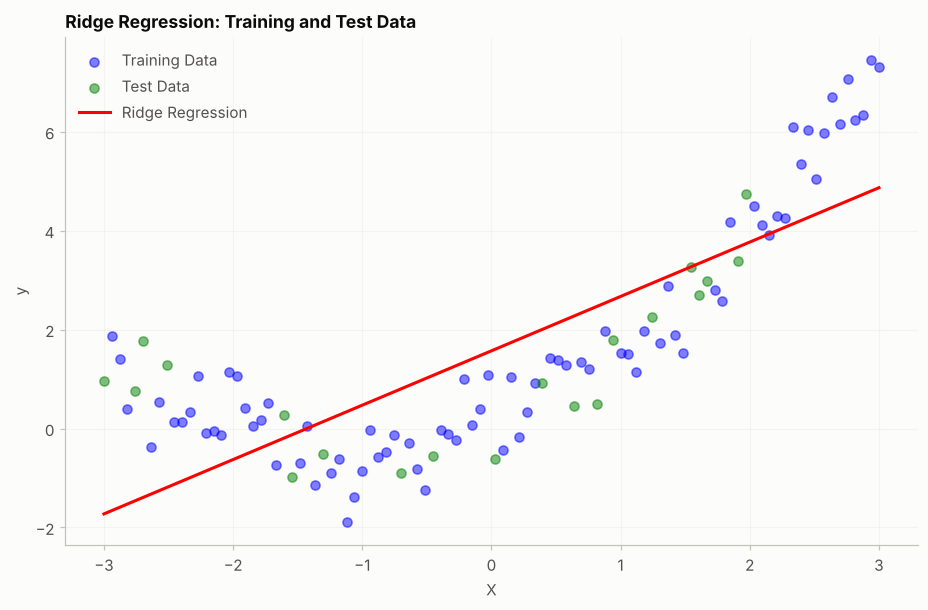

In [20]:
# BOOK CODE: Exercise 1 -- implementing ridge regression (p. 120; official solution from the book's repository)
# Load libraries
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic dataset with some noise
np.random.seed(123)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X.ravel()**2 + X.ravel() + np.random.normal(0, 0.5, 100)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Ridge regression model
ridge = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge.fit(X_train, y_train)

# Make predictions
y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = ridge.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Ridge Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Ridge Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training Metrics:
MSE: 0.2631
R²: 0.8814

Test Metrics:
MSE: 0.4239
R²: 0.8419


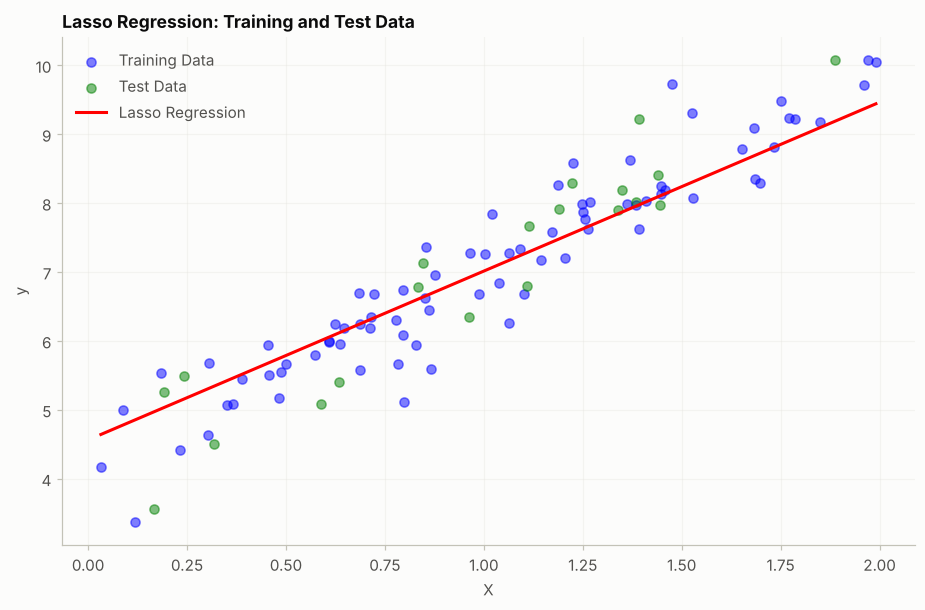

In [21]:
# BOOK CODE: Exercise 2 -- implementing Lasso regression (p. 121; official solution from the book's repository)
# Load libraries
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(123)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) * 0.5

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Lasso regression model
lasso = Lasso(alpha=0.1)  # alpha is the regularization strength
lasso.fit(X_train, y_train)

# Make predictions
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = lasso.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Lasso Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Lasso Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training Metrics:
MSE: 4.6771
R²: 0.9849

Test Metrics:
MSE: 4.0393
R²: 0.9867


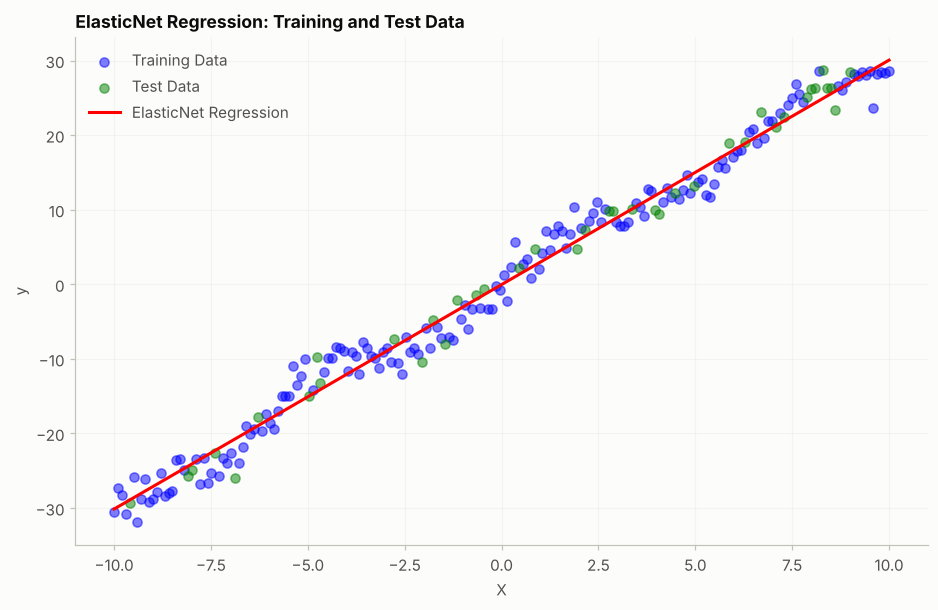

In [22]:
# BOOK CODE: Exercise 3 -- implementing ElasticNet regression (p. 121; official solution from the book's repository)
# Load libraries
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(123)
X = np.linspace(-10, 10, 200).reshape(-1, 1)
y = 3*X + np.sin(X) * 2 + np.random.normal(0, 1.5, X.shape)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit ElasticNet model
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # alpha is regularization strength, l1_ratio balances L1/L2
elastic_net.fit(X_train, y_train)

# Make predictions
y_pred_train = elastic_net.predict(X_train)
y_pred_test = elastic_net.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = elastic_net.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='ElasticNet Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('ElasticNet Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Output analysis.**

* **Exercise 1:**
  * The ridge line explains about two thirds of the training variance but scores a slightly **negative** $R^2$ on the test set.
  * The data are a parabola, and a straight line cannot follow it. Regularization is not the issue: with one feature and 80 points, `alpha=1` barely changes the OLS line.
  * On this particular test set (20 points), the line is systematically wrong at both ends of the curve, so it does worse than the test mean.
* **Exercise 2:**
  * The data really are a line ($y = 4 + 3x$), and Lasso fits them well ($R^2 \approx 0.84$ on the test set).
  * The fitted slope is visibly flatter than the true slope of 3: Lasso shrinks the only coefficient, and the unpenalized intercept rises to compensate (extra b).
* **Exercise 3:** a strong linear trend plus a small sine. ElasticNet captures the trend and reaches a test $R^2$ near 0.99. The remaining error is the sine and the noise, which no straight line can model.
* **The exercises' question — how do the three penalties compare?** — cannot really be answered on these data: each exercise uses a different dataset, with one feature and plenty of points. Extra (c) compares all four linear models on the same data.
* **A note on the official notebook.** It stores different numbers for these three cells (for example a test $R^2$ of 0.458 in exercise 1). NumPy's seeded legacy generator and the fixed split are reproducible, so the published code produces the values above; the stored outputs presumably come from earlier versions of the cells.

In [23]:
# EXTRA: (a) Exercise 1 with the right features -- ridge on [x, x^2] instead of x alone
np.random.seed(123)
X1 = np.linspace(-3, 3, 100).reshape(-1, 1)
y1 = 0.5 * X1.ravel() ** 2 + X1.ravel() + np.random.normal(0, 0.5, 100)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)
for name, model in [("Ridge on x (the solution)", Ridge(alpha=1.0)),
                    ("Ridge on [x, x^2]", make_pipeline(PolynomialFeatures(2, include_bias=False), Ridge(alpha=1.0)))]:
    model.fit(X1_train, y1_train)
    print(f"{name:26s}: training R2 {model.score(X1_train, y1_train):.3f} | test R2 {model.score(X1_test, y1_test):.3f}")

Ridge on x (the solution) : training R2 0.657 | test R2 -0.036
Ridge on [x, x^2]         : training R2 0.943 | test R2 0.890


In [24]:
# EXTRA: (b) How much does Lasso shrink the true slope? (exercise 2's data)
np.random.seed(123)
X2 = 2 * np.random.rand(100, 1)
y2 = 4 + 3 * X2 + np.random.randn(100, 1) * 0.5
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)
ols2 = LinearRegression().fit(X2_train, y2_train)
lasso2 = Lasso(alpha=0.1).fit(X2_train, y2_train)
predicted = ols2.coef_.item() - 0.1 / X2_train.var()
print(f"true line          : slope 3.000, intercept 4.000")
print(f"OLS                : slope {ols2.coef_.item():.3f}, intercept {ols2.intercept_.item():.3f}")
print(f"Lasso (alpha=0.1)  : slope {lasso2.coef_.item():.3f}, intercept {lasso2.intercept_.item():.3f}")
print(f"formula OLS slope - alpha / Var(x) = {ols2.coef_.item():.3f} - 0.1 / {X2_train.var():.3f} = {predicted:.3f}")
print(f"test R2: OLS {ols2.score(X2_test, y2_test):.3f} | Lasso {lasso2.score(X2_test, y2_test):.3f}")

true line          : slope 3.000, intercept 4.000
OLS                : slope 2.861, intercept 4.149
Lasso (alpha=0.1)  : slope 2.451, intercept 4.562
formula OLS slope - alpha / Var(x) = 2.861 - 0.1 / 0.244 = 2.451
test R2: OLS 0.883 | Lasso 0.842


In [25]:
# EXTRA: (c) The comparison the exercises ask for -- four linear models on the same data, 10-fold CV
cv10 = KFold(n_splits=10, shuffle=True, random_state=0)
datasets = {"exercise 1 (parabola)": (X1, y1), "exercise 2 (line)": (X2, y2.ravel()),
            "exercise 3 (line + sine)": (X, y.ravel())}
models = {"OLS": LinearRegression(), "Ridge (alpha=1)": Ridge(alpha=1.0), "Lasso (alpha=0.1)": Lasso(alpha=0.1),
          "ElasticNet (alpha=0.1, l1_ratio=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5)}
table = pd.DataFrame({ds: {name: cross_val_score(m, Xd_, yd_, cv=cv10, scoring="r2").mean() for name, m in models.items()}
                      for ds, (Xd_, yd_) in datasets.items()})
display(table.round(3))

,exercise 1 (parabola),exercise 2 (line),exercise 3 (line + sine)
OLS,0.265,0.883,0.985
Ridge (alpha=1),0.266,0.883,0.985
Lasso (alpha=0.1),0.276,0.869,0.985
"ElasticNet (alpha=0.1, l1_ratio=0.5)",0.277,0.840,0.985


**Output analysis.**

* **(a) The right features.** Giving ridge the squared feature turns exercise 1 from a negative test $R^2$ into a good fit (about 0.89). The model's flexibility, not its penalty, was the problem — the lesson of recipe 5 applied to the exercise.
* **(b) Lasso's shrinkage, by formula:**
  * OLS estimates the slope at about 2.86 (the noise hides the true 3).
  * Lasso's slope equals the OLS slope minus $\alpha/\operatorname{Var}(x)$, exactly as the formula predicts, and the intercept rises to keep the line through the centre of the data.
  * The test $R^2$ drops slightly compared with OLS, because the penalty only adds bias when the single feature truly matters.
* **(c) All four models on the same data:**
  * With one feature and 100–200 points, OLS, ridge, Lasso and ElasticNet perform almost identically on exercises 1 and 3: regularization has no variance to remove.
  * On exercise 2, the $L_1$-penalized models lose a few points, because shrinking the one truly relevant slope only adds bias.
  * The large differences *between* the exercises come from the data — a parabola cannot be fitted by a line.

  Regularization pays off with many correlated features and limited data (recipes 1–4), not here.

---
## Decision guide: choosing a linear model

| Situation | Model | Notes |
|---|---|---|
| Few features, many samples, interpretation of coefficients | `LinearRegression` | check VIFs; unstable coefficients signal multicollinearity |
| Many correlated features, all possibly relevant | `Ridge` / `RidgeCV` | standardize; tune `alpha` by cross-validation |
| Many features, most probably irrelevant | `Lasso` / `LassoCV` | gives a sparse model; with correlated features it keeps one at random |
| Correlated groups of features, or more features than samples | `ElasticNet` / `ElasticNetCV` | tune `alpha` and `l1_ratio`; correlated features enter together |
| A smooth non-linear relationship in one or a few features | `SplineTransformer` + linear model | choose the number of knots by cross-validation |
| Polynomial terms are needed (interactions, curvature) | `StandardScaler`, then `PolynomialFeatures`, then `Ridge` | scale before taking powers; regularize the many new columns |
| Uncertainty about the coefficients matters | `BayesianRidge`, `ARDRegression` | the penalty strength is estimated from the data |

## Chapter summary and key takeaways

| Recipe | Main tools | Key idea |
|---|---|---|
| Introduction to linear models | `LinearRegression`, `mean_squared_error`, `r2_score` | OLS projects the target onto the span of the features; multicollinearity makes coefficients unstable |
| Ridge and Lasso | `Ridge`, `Lasso`, `RidgeCV`, `LassoCV` | Ridge shrinks every coefficient; Lasso soft-thresholds and sets some exactly to zero |
| ElasticNet | `ElasticNet`, `enet_path`, `lasso_path` | Mixing $L_1$ and $L_2$ keeps sparsity and groups correlated features |
| Regularization theory | penalties as constraints, bias–variance, priors | A moderate penalty minimizes the test error; $L_1$'s corners create zeros |
| Polynomials and splines | `PolynomialFeatures`, `SplineTransformer` | Non-linear features keep the model linear in its coefficients; choose the complexity by cross-validation |
| Practical exercises | `Ridge`, `Lasso`, `ElasticNet` | With one feature, the choice of features matters far more than the penalty |

**Key takeaways**

1. Before blaming a model, check the data. In recipe 1 the target was generated before most of its informative columns were overwritten, and no model can recover that signal.
2. Regularization trades a little bias for a lot of variance. It pays off with many, correlated features — and only when its strength is tuned and the features are standardized.
3. Ridge shrinks, Lasso selects, ElasticNet selects while keeping correlated features together. scikit-learn's Lasso and ElasticNet scale the loss by $1/(2n)$, so their `alpha` is not comparable with `Ridge`'s.
4. Polynomial and spline features make linear models flexible. Scale before taking powers, and let cross-validation choose the degree or the number of knots.
5. Training MSE and $R^2$ always improve with complexity; held-out error is the only fair judge.

**Book (scikit-learn 1.5) vs. the version used here — notes from the reproduction**

* All listings and the three official exercise solutions run on scikit-learn 1.9.1.
* **One result changes:** the degree-5 polynomial in recipe 5 fails numerically. In scikit-learn 1.9, `LinearRegression`'s `tol` (default `1e-6`) is used as the singular-value cut-off of `scipy.linalg.lstsq` on dense data. Raw powers of $x \in [-50, 50]$ are scaled so differently that a direction is cut off. Standardizing $x$ first (or `tol=1e-10`) restores the book's finding that degree 5 is the best of the five.
* The first dataset adds unseeded noise, so its numbers differ between runs; this notebook fixes the global seed. Several listings trigger harmless warnings about feature names, because they fit on arrays and predict from DataFrames (or the reverse); the notebook silences them in the setup cell.
* The coefficient path listing uses the line styles `'solid'` and `'-'`, which are the same style, so two of its five `l1_ratio` values look identical.
* Small precisions to the chapter text:
  * The low $R^2$ of recipes 1–3 comes from the dataset construction (signal destroyed), not from multicollinearity.
  * scikit-learn's Lasso and ElasticNet losses carry a $1/(2n)$ factor that the book's formulas omit.
  * Ridge never sets coefficients to exactly zero, and "encouraging sparsity" is specific to $L_1$.
  * The non-linear dataset of recipe 5 is not built with `make_regression()` and has no exponential term.
  * The recipe's "spline interpolation" is spline regression.
  * The spline metrics are training-set metrics.
  * The hands-on list writes `SpineTransformer()` for `SplineTransformer()`.

## References

1. Sukup, J. (2025). *scikit-learn Cookbook* (3rd ed.). Packt Publishing. Code repository: <https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition>
2. Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: biased estimation for nonorthogonal problems. *Technometrics, 12*(1), 55–67.
3. Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B, 58*(1), 267–288.
4. Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B, 67*(2), 301–320.
5. Friedman, J., Hastie, T., & Tibshirani, R. (2010). Regularization paths for generalized linear models via coordinate descent. *Journal of Statistical Software, 33*(1), 1–22.
6. de Boor, C. (1978). *A Practical Guide to Splines*. Springer.
7. Eilers, P. H. C., & Marx, B. D. (1996). Flexible smoothing with B-splines and penalties. *Statistical Science, 11*(2), 89–121.
8. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
9. scikit-learn documentation: [Linear models](https://scikit-learn.org/stable/modules/linear_model.html) · [Preprocessing: polynomial and spline features](https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features) · [Lasso and ElasticNet paths](https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_lasso_lars_elasticnet_path.html) · [Underfitting vs. overfitting](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)